In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline

from IPython.display import display, HTML

### ✅ GPU Compute Benchmark란?

**GPU Compute Benchmark**는 PassMark의 PerformanceTest에서 제공하는 벤치마크로,  
OpenCL과 DirectCompute 같은 범용 GPU 연산(GPGPU) 환경에서 그래픽카드의 **실제 계산 성능**을 측정한 지표입니다.  
수백만 건의 테스트 결과를 기반으로 매일 업데이트되며, GPU가 병렬 연산 환경에서 얼마나 효율적으로 작동하는지를 나타냅니다.

- **OpenCL**: Khronos Group이 만든 범용 병렬 컴퓨팅 프레임워크  
- **DirectCompute**: Microsoft의 DirectX API 중 하나로, GPU에서 CPU처럼 범용 계산 수행  
- 두 방식 모두 **실제 연산 속도는 유사**하며, 이 벤치마크는 두 결과를 모두 반영하여 성능을 점수화합니다.

> 따라서, 이 벤치마크 점수는 GPU가 **실제 환경에서 어느 정도 계산 능력을 발휘하는지**를 보여주는 **현실적인 성능 지표**로 활용할 수 있습니다.

※ 이 기준은 [PassMark Software](https://www.passmark.com) 공식 GPU Compute Benchmark 페이지에서 제시한 내용을 기반으로 정리하였습니다.

---

### 📌 기타 GPU 스펙 정보 출처

이 프로젝트에서 사용된 **GPU의 기본적인 스펙 정보**는  
[TechPowerUp GPU Database](https://www.techpowerup.com/gpu-specs/)에서 크롤링한 데이터를 기반으로 수집되었습니다.

TechPowerUp은 다양한 GPU의 구조적 사양을 체계적으로 정리한 데이터베이스를 제공하는 사이트로, 모델별 세부 성능 및 하드웨어 정보를 확인할 수 있습니다.

In [3]:
# 출력 생략 방지를 위한 설정
pd.set_option('display.max_rows', 100)     # 최대 100행까지 출력
pd.set_option('display.max_columns', 100)  # 최대 100열까지 출력
pd.set_option('display.max_colwidth', 200) # 한 셀에 출력되는 최대 글자 수

In [4]:
# 데이터 불러오기
df_spec = pd.read_csv("./nvidia_gpu_spec_techpowerup.csv")
df_score = pd.read_csv("./nvidia_gpu_passmark_score.csv")

display(df_spec.shape)
display(df_spec.head())

display(df_score.shape)
display(df_score.head())

(1415, 75)

,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,Predecessor,Successor,Production,Bus Interface,Reviews,GPU Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Suggested PSU,Outputs,Power Connectors,DirectX,OpenGL,OpenCL,Vulkan,Pixel Shader,Vertex Shader,URL,Launch Price,GPU Variant,Board Number,Length,Vertex Rate,Width,Height,Weight,Chip Package,Shader Model,Shader Clock,Shading Units,SM Count,L2 Cache,FP32 (float),CUDA,Base Clock,Boost Clock,CUDA SDK,FP64 (double),Availability,L1 Cache,SMX Count,SMM Count,FP16 (half),Current Price,Storage,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,150 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t300 Mbps effective,32 MB,DDR,128 bit,4.800 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-ddr.c734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,143 MHz,32 MB,SDR,64 bit,1.144 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-sdr.c731,249 USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,NaN,Quadro2 Celcius,End-of-life,AGP 4x,26 in our database,135 MHz,166 MHz,32 MB,SDR,128 bit,2.656 GB/s,4.0,0.0,4.0,4.0,540.0 MPixel/s,540.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/quadro.c1374,NaN,NV10GL A3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,150 MHz,16 MB,SDR,128 bit,2.400 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2.c4130,NaN,Riva TNT2,22230350-005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,143 MHz,16 MB,SDR,64 bit,1.144 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2-m64.c1304,NaN,Riva TNT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


(1560, 2)

,Model Name,Score
0,GeForce RTX 4090,27172.0
1,RTX 6000 Ada Generation,24403.0
2,GeForce RTX 5090,23406.0
3,GeForce RTX 4080,21034.0
4,RTX 5000 Ada Generation,20708.0


In [5]:
import re

# 개선된 전처리 함수
def clean_name(name):
    name = str(name).lower()
    name = re.sub(r'[^a-z0-9]', '', name)
    name = name.replace('withmaxqdesign', 'maxq')
    name = name.replace('laptopgpu', 'mobile')
    return name

# Fuzzy match 함수
def fuzzy_match(score_name, spec_set):
    if score_name in spec_set:
        return score_name
    candidates = [s for s in spec_set if s.startswith(score_name)]
    clean_candidates = [s for s in candidates
                        if 'mobile' not in s and 'maxq' not in s]
    if clean_candidates:
        return min(clean_candidates, key=len)
    return None

# 전처리 적용
df_spec['model_key'] = df_spec['Model Name'].apply(clean_name)
df_score['model_key'] = df_score['Model Name'].apply(clean_name)

# 중복 확인
dup_count = df_score['model_key'].duplicated().sum()
print(f"df_score 중복 모델명 수: {dup_count}")

spec_set = set(df_spec['model_key'])

# score 모델에 fuzzy match 적용
df_score['model_key'] = df_score['model_key'].apply(
    lambda x: fuzzy_match(x, spec_set) or x
)

# 병합
df = pd.merge(df_spec, df_score.drop(columns='Model Name'),
              on='model_key', how='left')
df.drop(columns='model_key', inplace=True)

# 매칭 결과 확인
matched = df['Score'].notnull().sum()
total = len(df)
print(f"매칭 성공: {matched}/{total} ({matched/total*100:.1f}%)")
df.head()

df_score 중복 모델명 수: 8
매칭 성공: 470/1426 (33.0%)


,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,Predecessor,Successor,Production,Bus Interface,Reviews,GPU Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Suggested PSU,Outputs,Power Connectors,DirectX,OpenGL,OpenCL,Vulkan,Pixel Shader,Vertex Shader,URL,Launch Price,GPU Variant,Board Number,Length,Vertex Rate,Width,Height,Weight,Chip Package,Shader Model,Shader Clock,Shading Units,SM Count,L2 Cache,FP32 (float),CUDA,Base Clock,Boost Clock,CUDA SDK,FP64 (double),Availability,L1 Cache,SMX Count,SMM Count,FP16 (half),Current Price,Storage,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced,Score
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,150 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t300 Mbps effective,32 MB,DDR,128 bit,4.800 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-ddr.c734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,143 MHz,32 MB,SDR,64 bit,1.144 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-sdr.c731,249 USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,NaN,Quadro2 Celcius,End-of-life,AGP 4x,26 in our database,135 MHz,166 MHz,32 MB,SDR,128 bit,2.656 GB/s,4.0,0.0,4.0,4.0,540.0 MPixel/s,540.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/quadro.c1374,NaN,NV10GL A3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,150 MHz,16 MB,SDR,128 bit,2.400 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2.c4130,NaN,Riva TNT2,22230350-005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,143 MHz,16 MB,SDR,64 bit,1.144 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2-m64.c1304,NaN,Riva TNT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# 상위 5개 행 확인
print("🔹 데이터 미리보기:")
display(df.head())

# 데이터프레임 정보 확인
print("\n🔹 데이터 요약 정보:")
df.info()

# 결측치 개수 확인
print("\n🔹 결측치 개수:")
print(df.isnull().sum())

# 기술통계 (수치형 변수 기준)
print("\n🔹 수치형 변수 통계:")
display(df.describe())

# 범주형 변수 비율 확인
print("\n🔹 범주형 변수 값 분포 예시:")
for col in df.select_dtypes(include='object').columns[:5]:
    print(f"\n▶ {col}")
    print(df[col].value_counts().head())

🔹 데이터 미리보기:


,Model Name,GPU Name,Architecture,Foundry,Process Size,Transistors,Density,Die Size,Release Date,Generation,Predecessor,Successor,Production,Bus Interface,Reviews,GPU Clock,Memory Clock,Memory Size,Memory Type,Memory Bus,Bandwidth,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Suggested PSU,Outputs,Power Connectors,DirectX,OpenGL,OpenCL,Vulkan,Pixel Shader,Vertex Shader,URL,Launch Price,GPU Variant,Board Number,Length,Vertex Rate,Width,Height,Weight,Chip Package,Shader Model,Shader Clock,Shading Units,SM Count,L2 Cache,FP32 (float),CUDA,Base Clock,Boost Clock,CUDA SDK,FP64 (double),Availability,L1 Cache,SMX Count,SMM Count,FP16 (half),Current Price,Storage,Tensor Cores,RT Cores,BF16,TF32,FP64 Tensor,NVENC,NVDEC,Process Type,Announced,Score
0,GeForce 256 DDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Dec 23rd, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,150 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t300 Mbps effective,32 MB,DDR,128 bit,4.800 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-ddr.c734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GeForce 256 SDR,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,"Oct 11th, 1999",GeForce 256,TNT2,GeForce 2,End-of-life,AGP 4x,1 in our database,120 MHz,143 MHz,32 MB,SDR,64 bit,1.144 GB/s,4.0,0.0,4.0,4.0,480.0 MPixel/s,480.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/geforce-256-sdr.c731,249 USD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Quadro,NV10,Celsius,TSMC,220 nm,17 million,122.3K / mm²,139 mm²,1999,Quadro Celsius,NaN,Quadro2 Celcius,End-of-life,AGP 4x,26 in our database,135 MHz,166 MHz,32 MB,SDR,128 bit,2.656 GB/s,4.0,0.0,4.0,4.0,540.0 MPixel/s,540.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,7.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/quadro.c1374,NaN,NV10GL A3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Riva TNT2,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,150 MHz,16 MB,SDR,128 bit,2.400 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2.c4130,NaN,Riva TNT2,22230350-005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Riva TNT2 M64,NV5,Fahrenheit,TSMC,250 nm,15 million,238.1K / mm²,63 mm²,"Oct 12th, 1999",TNT2,Riva,GeForce 256,End-of-life,AGP 4x,1 in our database,125 MHz,143 MHz,16 MB,SDR,64 bit,1.144 GB/s,2.0,0.0,2.0,2.0,250.0 MPixel/s,250.0 MTexel/s,Single-slot,unknown,200 W,1x VGA,NaN,6.0,1.2,NaN,NaN,NaN,NaN,https://www.techpowerup.com/gpu-specs/riva-tnt2-m64.c1304,NaN,Riva TNT2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



🔹 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426 entries, 0 to 1425
Data columns (total 76 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Model Name        1426 non-null   object 
 1   GPU Name          1426 non-null   object 
 2   Architecture      1426 non-null   object 
 3   Foundry           1372 non-null   object 
 4   Process Size      1426 non-null   object 
 5   Transistors       1426 non-null   object 
 6   Density           1402 non-null   object 
 7   Die Size          1426 non-null   object 
 8   Release Date      1426 non-null   object 
 9   Generation        1426 non-null   object 
 10  Predecessor       1261 non-null   object 
 11  Successor         1238 non-null   object 
 12  Production        1426 non-null   object 
 13  Bus Interface     1419 non-null   object 
 14  Reviews           682 non-null    object 
 15  GPU Clock         835 non-null    object 
 16  Memory Clock      1426 non-n

,Pixel Shaders,Vertex Shaders,TMUs,ROPs,Shading Units,SM Count,CUDA,CUDA SDK,SMX Count,SMM Count,Tensor Cores,RT Cores,Score
count,319.000000,319.000000,1426.000000,1426.000000,1107.000000,841.000000,1079.000000,12.0,167.000000,99.000000,264.000000,207.000000,470.000000
mean,7.442006,2.996865,72.533661,28.985273,1794.789521,22.822830,4.397312,6.5,5.293413,7.535354,274.060606,47.130435,3037.312766
std,7.480095,2.739759,100.796188,34.277942,3046.367096,29.450414,2.819486,0.0,4.375880,5.916620,178.519461,28.414023,4143.726413
min,2.000000,0.000000,1.000000,1.000000,8.000000,1.000000,1.000000,6.5,1.000000,1.000000,16.000000,6.000000,9.000000
25%,2.000000,1.000000,8.000000,4.000000,96.000000,3.000000,2.000000,6.5,2.000000,3.000000,120.000000,28.000000,517.000000
50%,4.000000,3.000000,32.000000,16.000000,448.000000,12.000000,3.500000,6.5,4.000000,5.000000,240.000000,40.000000,1316.500000
75%,8.000000,5.000000,80.000000,32.000000,2304.000000,30.000000,7.500000,6.5,8.000000,10.000000,388.000000,58.000000,4074.500000
max,48.000000,24.000000,576.000000,192.000000,18432.000000,144.000000,10.100000,6.5,15.000000,24.000000,640.000000,144.000000,27172.000000



🔹 범주형 변수 값 분포 예시:

▶ Model Name
Model Name
GeForce GT 635M     8
ION                 5
GeForce 6800 XT     4
GeForce 405 OEM     3
GeForce 6200 AGP    3
Name: count, dtype: int64

▶ GPU Name
GPU Name
GK104    52
GK107    48
GF108    41
GM107    30
GA107    28
Name: count, dtype: int64

▶ Architecture
Architecture
Tesla     177
Curie     168
Kepler    139
Ampere    120
Pascal     95
Name: count, dtype: int64

▶ Foundry
Foundry
TSMC       1205
Samsung     135
UMC          28
Sony          4
Name: count, dtype: int64

▶ Process Size
Process Size
28 nm    285
40 nm    224
12 nm    114
8 nm     101
90 nm     89
Name: count, dtype: int64


In [7]:
# 타겟 변수 'Score'를 기준으로 결측 행 제거
initial_shape = df.shape
df = df[df["Score"].notnull()]
removed_score_rows = initial_shape[0] - df.shape[0]
print(f"🧹 'Score' 결측으로 제거된 행 수: {removed_score_rows}")
print(f"   제거 전: {initial_shape[0]}행 → 제거 후: {df.shape[0]}행\n")

🧹 'Score' 결측으로 제거된 행 수: 956
   제거 전: 1426행 → 제거 후: 470행



In [8]:
# 결측 비율 계산
col_null_ratio = df.isnull().mean()

null_summary = pd.DataFrame({
    "MissingRatio": col_null_ratio,
    "Over50%": col_null_ratio >= 0.5,
    "Over70%": col_null_ratio >= 0.7
}).sort_values("MissingRatio", ascending=False)

# 결측 비율 50% 이상 컬럼 확인
print("🔹 결측률 50% 이상 컬럼:")
display(null_summary[null_summary["MissingRatio"] > 0.5])

# 50% 이상 결측 컬럼 제거
cols_to_drop = null_summary[null_summary["Over50%"]].index
before_shape = df.shape
df = df.drop(columns=cols_to_drop)
print(f"\n🧹 50% 이상 결측 컬럼 제거 완료!")
print(f"   제거된 컬럼 수: {len(cols_to_drop)}개 | {before_shape[1]}열 → {df.shape[1]}열")

# 참고: 50% 이상 70% 미만 컬럼 목록
print(f"\n🔹 50% 이상 70% 미만 결측 컬럼 (제거된 항목 중):")
display(null_summary[(null_summary["MissingRatio"] >= 0.5) & (null_summary["MissingRatio"] < 0.7)])

🔹 결측률 50% 이상 컬럼:


,MissingRatio,Over50%,Over70%
Weight,1.000000,True,True
Storage,1.000000,True,True
Announced,1.000000,True,True
Process Type,1.000000,True,True
NVDEC,1.000000,True,True
Vertex Shader,1.000000,True,True
NVENC,1.000000,True,True
FP64 Tensor,1.000000,True,True
TF32,1.000000,True,True
Pixel Shader,1.000000,True,True



🧹 50% 이상 결측 컬럼 제거 완료!
   제거된 컬럼 수: 31개 | 76열 → 45열

🔹 50% 이상 70% 미만 결측 컬럼 (제거된 항목 중):


,MissingRatio,Over50%,Over70%
Power Connectors,0.697872,True,False
Launch Price,0.691489,True,False
FP16 (half),0.634043,True,False
GPU Clock,0.634043,True,False
Reviews,0.589362,True,False
Length,0.542553,True,False
Suggested PSU,0.514894,True,False


### 🔍 결측률 50% 이상 70% 미만 컬럼 제거 사유

다음 컬럼들은 결측률이 50% 이상이지만 70% 미만으로, 완전 삭제를 망설일 수 있는 범위입니다. 그러나 **벤치마크 점수(`Score`) 예측이라는 분석 목적**과의 관련성이 낮거나 불확실하여 제거 대상으로 판단했습니다.

| 변수명 | 결측률 | 설명 | 제거 사유 |
|--------|--------|------|------------|
| **Shader Clock** | 67.8% | GPU의 쉐이더 클럭 속도 (과거에는 중요했으나 현재는 잘 사용되지 않음) | 현대 GPU에서는 Boost Clock 위주로 동작하며, Shader Clock은 명확하지 않거나 측정 불가한 경우가 많아 성능 예측 변수로서 부적절 |
| **Width** | 66.8% | 메모리 인터페이스 폭 (ex. 128-bit, 256-bit) | 메모리 대역폭의 일부를 구성하지만, 대역폭 전체와 DRAM 종류, 캐시 구조 등 복합 요소가 성능에 영향을 주므로 단독으로 쓰기 어려움 |
| **Power Connectors** | 65.2% | 보조 전원 커넥터 수 및 타입 (예: 6-pin, 8-pin) | 전력 공급 한계는 나타내지만, 아키텍처에 따라 전력 효율이 다르기 때문에 `Score`와 직접적 상관이 낮음 |
| **Launch Price** | 63.4% | 출시 당시 가격 (달러 기준) | 가격은 시장 포지셔닝과 브랜드 전략에 따라 결정되므로, 성능과 반드시 비례하지 않음 |
| **GPU Clock** | 58.9% | GPU의 기본 클럭 속도 (MHz) | 실제 성능은 Boost Clock 및 병렬 구조에 더 좌우되므로 단독으로는 예측력 낮음 |
| **Reviews** | 54.5% | 유저/매체의 리뷰 수 | 주관적 평가는 벤치마크 점수의 정량적 수치와 무관하며, 누락된 값도 많고 일관성 부족 |

> 🔎 이 컬럼들은 대부분 구형 GPU에서의 측정 누락 또는 현대 GPU에서의 비활성화된 개념이며, 결측률이 높아 학습 데이터의 불확실성을 높이므로 **모델의 일반화 성능에 부정적 영향을 줄 수 있어 제거**는 것이 합리적입니다.


In [10]:
# ✅ 추가 결측 제거 이후, 데이터 상태 다시 점검

# 데이터프레임 정보 확인
print("\n🔹 [After Drop] 데이터 요약 정보:")
df.info()

# 결측치 개수 확인
print("\n🔹 [After Drop] 컬럼별 결측치 개수:")
print(df.isnull().sum())


🔹 [After Drop] 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 470 entries, 131 to 1425
Data columns (total 45 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model Name     470 non-null    object 
 1   GPU Name       470 non-null    object 
 2   Architecture   470 non-null    object 
 3   Foundry        465 non-null    object 
 4   Process Size   470 non-null    object 
 5   Transistors    470 non-null    object 
 6   Density        469 non-null    object 
 7   Die Size       470 non-null    object 
 8   Release Date   470 non-null    object 
 9   Generation     470 non-null    object 
 10  Predecessor    424 non-null    object 
 11  Successor      411 non-null    object 
 12  Production     470 non-null    object 
 13  Bus Interface  470 non-null    object 
 14  Memory Clock   470 non-null    object 
 15  Memory Size    470 non-null    object 
 16  Memory Type    470 non-null    object 
 17  Memory Bus     470 non-null  

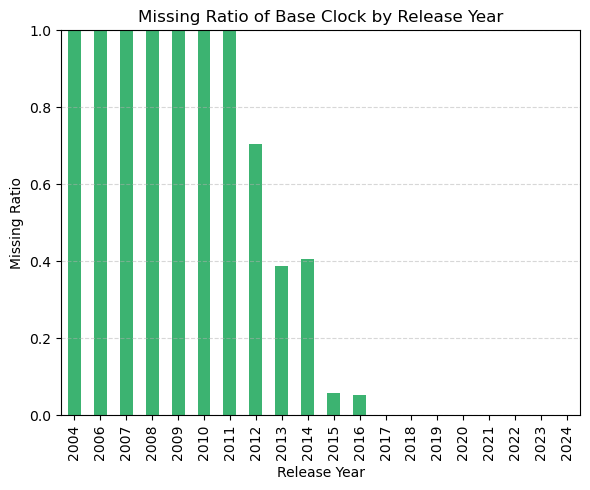

In [11]:
# 날짜 문자열을 datetime으로 변환하고 연도 추출
df['Release_Year'] = pd.to_datetime(df['Release Date'], errors='coerce').dt.year

# 연도별 Base Clock 결측 비율 계산
yearly_null_ratio = df.groupby('Release_Year', observed=True)['Base Clock'].apply(
    lambda x: x.isnull().mean()
)

# ⚠️ Base Clock은 임의 보간이 어려운 GPU 핵심 스펙 중 하나
# 최신 GPU로 갈수록 해당 정보가 잘 기록되는 경향이 있으며,
# 이는 미래 세대 예측의 현실적인 특성을 반영하므로 해당 변수를 기준으로 데이터를 보존하여 분석

plt.figure(figsize=(6, 5))
yearly_null_ratio.plot(kind='bar', color='#3CB371')
plt.title('Missing Ratio of Base Clock by Release Year')
plt.ylabel('Missing Ratio')
plt.xlabel('Release Year')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(ticks=range(len(yearly_null_ratio)), labels=yearly_null_ratio.index.astype('Int64'))
plt.tight_layout()
plt.show()

# Release_Year는 시각화용 임시 컬럼이므로 제거
df.drop(columns=['Release_Year'], inplace=True)

In [12]:
# Base Clock이 결측된 행들(n=158)은 Boost Clock(100%)을 비롯해, L1 Cache(~51%) 등 다른 성능 변수들도 누락
# 이런 행들은 대부분 오래된 GPU로, 정보 자체가 기록되어 있지 않아 크롤링 과정에서도 얻을 수 없었음
# 따라서 본 분석에서는 신뢰 가능한 성능 데이터를 기반으로 하기 위해, Base Clock이 결측인 행은 모두 제거

# Base Clock 결측 행 분석 및 제거
missing_base_clock = df[df["Base Clock"].isnull()]
print(f"⚠️ Base Clock 결측 행 수: {len(missing_base_clock)}")

# 결측 행들의 컬럼별 결측 비율 확인
null_ratio = missing_base_clock.isnull().mean()
non_zero_nulls = null_ratio[null_ratio > 0].sort_values(ascending=False)
display(non_zero_nulls)

# Base Clock 결측 행 제거
before = df.shape[0]
df = df[df["Base Clock"].notnull()]
print(f"\n🧹 Base Clock 결측 행 제거 완료!")
print(f"   {before}행 → {df.shape[0]}행 ({before - df.shape[0]}행 제거)")

⚠️ Base Clock 결측 행 수: 172


Boost Clock      1.000000
Base Clock       1.000000
Vulkan           0.784884
Board Number     0.418605
SM Count         0.220930
GPU Variant      0.197674
Predecessor      0.133721
Successor        0.133721
FP64 (double)    0.127907
L1 Cache         0.116279
Slot Width       0.040698
Chip Package     0.034884
L2 Cache         0.029070
CUDA             0.029070
OpenCL           0.029070
Foundry          0.029070
FP32 (float)     0.005814
Shading Units    0.005814
Density          0.005814
dtype: float64


🧹 Base Clock 결측 행 제거 완료!
   470행 → 298행 (172행 제거)


### 🔍 GPU 변수별 활용 판단 요약

| 변수명 | 의미 | 결측치 개수 | 활용 판단 | 판단 근거 |
|--------|------|-------------|-----------|-----------|
| Model Name | 제품 모델명 | 0 | 식별용 | 학습 시 드랍, 결과 확인용으로 보존 |
| GPU Name | GPU 칩 이름 | 0 | 불필요 | 카디널리티 과다, OHE 비효율 |
| **Architecture** | **GPU 아키텍처 명칭** | **0** | **필요** | **세대별 성능 차이를 설명하는 핵심 변수, OHE 처리** |
| Foundry | 제조사(파운드리) | 0 | 필요 | 기술력 구분, 바이너리 처리 가능 |
| Process Size | 공정 크기 (nm) | 0 | 필요 | 성능/전력 효율과 직접 관련 |
| Transistors | 트랜지스터 개수 | 0 | 필요 | 성능 수준 비교에 활용 |
| Density | 트랜지스터 밀도 | 0 | 필요 | 제조 효율성과 성능에 영향 |
| Die Size | 다이 면적 (mm²) | 0 | 필요 | 공정 밀도 및 기술력 평가에 유용 |
| Release Date | 출시일 | 0 | 불필요 | Architecture와 강한 상관, 중복 정보 |
| Generation | 세대 구분 | 0 | 불필요 | Architecture와 강한 상관, 중복 정보 |
| Predecessor | 전 세대 모델 | 22 | 불필요 | 모델 간 연결 정보, 분석 가치 낮음 |
| Successor | 후속 모델 | 26 | 불필요 | 위와 같음 |
| Production | 생산 상태 | 0 | 불필요 | 시장 유통 여부는 분석과 무관 |
| Bus Interface | 인터페이스 종류 | 0 | 불필요 | GPU 연산 성능보다 CPU-GPU 통신 영향, Compute Benchmark 영향 적음 |
| Memory Clock | 메모리 클럭 | 0 | 필요 | 메모리 성능에 직접 영향 |
| Memory Size | 메모리 용량 | 0 | 필요 | 메모리 사양 중 핵심 지표 |
| Memory Type | 메모리 종류 (GDDR6 등) | 0 | 필요 | 성능 구분에 핵심적인 분류 기준, OHE 처리 |
| Memory Bus | 메모리 버스 폭 (bit) | 0 | 필요 | 대역폭과 직접적인 상관 |
| Bandwidth | 메모리 대역폭 (GB/s) | 0 | 필요 | 전송 속도 평가의 핵심 지표 |
| TMUs | 텍스처 매핑 유닛 수 | 0 | 필요 | 그래픽 처리 성능에 영향 |
| ROPs | 렌더 출력 유닛 수 | 0 | 필요 | 렌더링 성능 판단 기준 |
| Pixel Rate | 픽셀 처리 속도 | 0 | 필요 | 픽셀 렌더링 성능 관련 |
| Texture Rate | 텍스처 처리 속도 | 0 | 필요 | TMU 성능과 관련된 지표 |
| Slot Width | 장착 슬롯 형태 및 크기 | 11 | 필요 | 고성능 GPU일수록 Dual 이상 슬롯, Ordinal 인코딩 가능 |
| TDP | 열 설계 전력 (W) | 0 | 필요 | 전력 효율 및 발열 관리에 필수 |
| **Suggested PSU** | **권장 파워 용량 (W)** | **108** | **불필요** | **TDP에서 파생되는 값, 중복 정보 + 성능 무관** |
| Outputs | 출력 포트 구성 | 0 | 불필요 | 활용 목적에 가까움, 성능과 무관 |
| DirectX | 지원 DirectX 버전 | 0 | 불필요 | Architecture에 의해 결정됨, 중복 |
| OpenGL | 지원 OpenGL 버전 | 0 | 불필요 | 위와 같음 |
| OpenCL | 지원 OpenCL 버전 | 0 | 불필요 | 위와 같음 |
| Vulkan | 지원 Vulkan 버전 | 1 | 불필요 | 위와 같음 |
| URL | 제품 상세 페이지 URL | 0 | 불필요 | 크롤링 출처일 뿐 분석과 무관 |
| GPU Variant | 세부 GPU 버전 | 54 | 불필요 | 변별력 낮고 결측 많음 |
| Board Number | 기판 번호 | 71 | 불필요 | 식별자 성격, 분석과 무관 |
| **Length** | **그래픽카드 길이 (mm)** | **112** | **불필요** | **케이스 호환성 정보, 성능과 무관** |
| Chip Package | 칩 패키징 정보 | 28 | 불필요 | 비정형 텍스트, 결측 많음 |
| Shader Model | 셰이더 모델 버전 | 0 | 불필요 | Architecture에 의해 결정됨, 중복 |
| Shading Units | 셰이딩 유닛 수 | 0 | 필요 | 병렬 연산 핵심 지표 (= SM Count × cores/SM) |
| **SM Count** | **Streaming Multiprocessor 개수** | **121** | **필요** | **GPU 연산 성능의 곱셈 인자, 결측은 다중공선성으로 VIF가 처리** |
| L2 Cache | L2 캐시 용량 | 1 | 필요 | 연산 성능과 밀접한 관련 |
| FP32 (float) | 단정밀도 부동소수점 성능 | 0 | 필요 | 구조적 성능 비교 핵심 |
| **CUDA** | **CUDA Compute Capability 버전** | **0** | **불필요** | **Architecture와 1:1 대응되는 세대 식별자, 중복 정보** |
| Base Clock | 기본 클럭 | 0 | 필요 | 연산 성능 기본 속도 (결측 행 이미 제거됨) |
| Boost Clock | 부스트 클럭 | 0 | 필요 | 최대 성능 판단 기준 |
| FP64 (double) | 배정밀도 부동소수점 성능 | 0 | 필요 | 정밀 연산 기준 |
| L1 Cache | L1 캐시 용량 | 1 | 필요 | 연산 관련 성능 지표 |
| Score | 종합 점수 | 0 | 필요 | ⭐ 타겟 변수 y |

In [32]:
# 🎯 변수 의미 기반 컬럼 분류 후 제거

# (A) 성능과 직접 무관한 변수
performance_irrelevant = [
    'Outputs', 'URL', 'Board Number', 'GPU Variant',
    'Length', 'Suggested PSU', 'Chip Package',
    'Predecessor', 'Successor', 'Production', 'Bus Interface',
]

# (B) Architecture와 강한 상관 → 중복 정보로 제거
redundant_with_architecture = [
    'Generation', 'Release Date', 'Shader Model',
    'DirectX', 'OpenGL', 'OpenCL', 'Vulkan', 'CUDA',
]

# (C) 카디널리티 과다
high_cardinality = ['GPU Name']

# (D) 다른 변수와 정보 중복 (실용적 선택)
# SM Count: Shading Units = SM Count × cores_per_SM 관계로 정보 중복
# 결측 121행을 살리려면 보간이 필요한데, Shading Units가 이미 같은 정보를 담고 있어 제거
redundant_with_others = ['SM Count']

# 최종 제거
drop_cols = (performance_irrelevant + redundant_with_architecture 
             + high_cardinality + redundant_with_others)
df.drop(columns=drop_cols, inplace=True, errors='ignore')

print(f"🧹 의미 기반 컬럼 제거 완료!")
print(f"   제거된 컬럼 수: {len(drop_cols)}개")
print(f"   남은 컬럼 수: {df.shape[1]}개")

# 'unknown'인 TDP 값 제거
before = df.shape[0]
df = df[df["TDP"] != "unknown"]
print(f"\n🧹 TDP='unknown' 행 제거: {before - df.shape[0]}행")

# 잔여 결측 행 제거
before = df.shape[0]
df = df.dropna()
print(f"🧹 잔여 결측 행 제거: {before - df.shape[0]}행")
print(f"\n📊 최종 shape: {df.shape}")

🧹 의미 기반 컬럼 제거 완료!
   제거된 컬럼 수: 21개
   남은 컬럼 수: 26개

🧹 TDP='unknown' 행 제거: 10행
🧹 잔여 결측 행 제거: 27행

📊 최종 shape: (261, 26)


In [34]:
# ✅ 의미 기반 컬럼 제거 + 결측/이상치 제거 이후 데이터 상태 점검

print("\n🔹 [After Drop] 데이터 요약 정보:")
df.info()

print("\n🔹 [After Drop] 컬럼별 결측치 개수:")
print(df.isnull().sum())


🔹 [After Drop] 데이터 요약 정보:
<class 'pandas.core.frame.DataFrame'>
Index: 261 entries, 723 to 1425
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model Name     261 non-null    object 
 1   Architecture   261 non-null    object 
 2   Foundry        261 non-null    object 
 3   Process Size   261 non-null    object 
 4   Transistors    261 non-null    object 
 5   Density        261 non-null    object 
 6   Die Size       261 non-null    object 
 7   Memory Clock   261 non-null    object 
 8   Memory Size    261 non-null    object 
 9   Memory Type    261 non-null    object 
 10  Memory Bus     261 non-null    object 
 11  Bandwidth      261 non-null    object 
 12  TMUs           261 non-null    float64
 13  ROPs           261 non-null    float64
 14  Pixel Rate     261 non-null    object 
 15  Texture Rate   261 non-null    object 
 16  Slot Width     261 non-null    object 
 17  TDP            261 non-null  

In [36]:
import re

# === 수치 추출 및 단위 변환 함수들 ===

def extract_number(value, scale=1):
    """문자열에서 첫 번째 숫자를 추출하고 scale 적용"""
    try:
        number = re.findall(r"[\d.]+", str(value).replace(",", ""))[0]
        return float(number) * scale
    except (IndexError, ValueError, AttributeError):
        return None

def convert_transistors(value):
    """트랜지스터 수: 'million' 단위를 실제 개수로"""
    s = str(value)
    if "million" in s.lower():
        return extract_number(s, scale=1_000_000)
    elif "billion" in s.lower():
        return extract_number(s, scale=1_000_000_000)
    else:
        return extract_number(s)

def convert_memory_size(value):
    """메모리 용량: GB 기준으로 통일"""
    s = str(value)
    if "GB" in s:
        return extract_number(s, scale=1)
    elif "MB" in s:
        return extract_number(s, scale=1/1024)
    else:
        return None

def convert_cache(value):
    """캐시 용량: MB 기준으로 통일"""
    s = str(value)
    if "MB" in s:
        return extract_number(s, scale=1)
    elif "KB" in s:
        return extract_number(s, scale=1/1024)
    else:
        return None

def convert_flops(value):
    """FLOPS 성능: GFLOPS 기준으로 통일 (FP32, FP64 공용)"""
    s = str(value)
    if "TFLOPS" in s:
        return extract_number(s, scale=1000)
    elif "GFLOPS" in s:
        return extract_number(s, scale=1)
    else:
        return None


# === 각 컬럼별 전처리 ===
df["Process Size"]  = df["Process Size"].apply(extract_number)
df["Transistors"]   = df["Transistors"].apply(convert_transistors)
df["Density"]       = df["Density"].apply(extract_number)
df["Die Size"]      = df["Die Size"].apply(extract_number)
df["Memory Size"]   = df["Memory Size"].apply(convert_memory_size)
df["Memory Bus"]    = df["Memory Bus"].apply(extract_number)
df["Bandwidth"]     = df["Bandwidth"].apply(extract_number)
df["Pixel Rate"]    = df["Pixel Rate"].apply(extract_number)
df["Texture Rate"]  = df["Texture Rate"].apply(extract_number)
df["TDP"]           = df["TDP"].apply(extract_number)
df["L2 Cache"]      = df["L2 Cache"].apply(convert_cache)
df["L1 Cache"]      = df["L1 Cache"].apply(convert_cache)
df["FP32 (float)"]  = df["FP32 (float)"].apply(convert_flops)
df["FP64 (double)"] = df["FP64 (double)"].apply(convert_flops)
df["Base Clock"]    = df["Base Clock"].apply(extract_number)
df["Boost Clock"]   = df["Boost Clock"].apply(extract_number)

# 변환 후 결측 발생 여부 확인
converted_cols = [
    "Process Size", "Transistors", "Density", "Die Size", "Memory Size",
    "Memory Bus", "Bandwidth", "Pixel Rate", "Texture Rate", "TDP",
    "L2 Cache", "L1 Cache", "FP32 (float)", "FP64 (double)",
    "Base Clock", "Boost Clock"
]
nan_check = df[converted_cols].isnull().sum()
nan_cols = nan_check[nan_check > 0]
if len(nan_cols) > 0:
    print("⚠️ 변환 실패로 NaN 발생한 컬럼:")
    print(nan_cols)
else:
    print("✅ 모든 변환 성공, NaN 없음")

# 결과 확인
display(df[converted_cols].head())

✅ 모든 변환 성공, NaN 없음


,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,Pixel Rate,Texture Rate,TDP,L2 Cache,L1 Cache,FP32 (float),FP64 (double),Base Clock,Boost Clock
723,28.0,1.270000e+09,10.8,118.0,2.0,128.0,28.8,5.672,22.69,32.0,0.25,0.015625,544.5,22.69,624.0,709.0
724,28.0,1.270000e+09,10.8,118.0,1.0,128.0,28.8,4.560,18.24,20.0,0.25,0.015625,437.8,18.24,500.0,570.0
727,28.0,1.270000e+09,10.8,118.0,2.0,128.0,28.8,6.240,24.96,32.0,0.25,0.015625,599.0,24.96,709.0,780.0
728,28.0,1.270000e+09,10.8,118.0,2.0,128.0,28.8,6.240,24.96,32.0,0.25,0.015625,599.0,24.96,709.0,780.0
729,28.0,1.270000e+09,10.8,118.0,1.0,128.0,28.8,7.600,30.40,45.0,0.25,0.015625,729.6,30.40,835.0,950.0


In [38]:
# === Memory Clock: 두 컬럼으로 분리 ===
def parse_memory_clock(value):
    parts = str(value).split('\n')
    mhz_match = re.search(r"(\d+\.?\d*)\s*MHz", parts[0])
    rate_match = re.search(r"(\d+\.?\d*)\s*(Gbps|Mbps)", parts[-1])
    
    clock_mhz = float(mhz_match.group(1)) if mhz_match else None
    
    if rate_match:
        rate = float(rate_match.group(1))
        unit = rate_match.group(2)
        if unit == "Gbps":
            rate *= 1000  # Gbps → Mbps
    else:
        rate = None
    
    return pd.Series([clock_mhz, rate])

df[["Memory Clock (MHz)", "Memory Transfer Rate (Mbps)"]] = df["Memory Clock"].apply(parse_memory_clock)

# 변환 결과 확인
nan_check = df[["Memory Clock (MHz)", "Memory Transfer Rate (Mbps)"]].isnull().sum()
if nan_check.sum() > 0:
    print("⚠️ Memory Clock 변환 실패한 행:")
    print(df[df["Memory Clock (MHz)"].isnull()]["Memory Clock"].head())
else:
    print("✅ Memory Clock 분리 완료, NaN 없음")

display(df[["Memory Clock", "Memory Clock (MHz)", "Memory Transfer Rate (Mbps)"]].head())
df = df.drop(columns=["Memory Clock"])

✅ Memory Clock 분리 완료, NaN 없음


,Memory Clock,Memory Clock (MHz),Memory Transfer Rate (Mbps)
723,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
724,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
727,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
728,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0
729,900 MHz\n\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t1800 Mbps effective,900.0,1800.0


In [40]:
# === 범주형 변수 인코딩 ===

# Architecture - Fermi 2.0은 표본 1개로 학습/검증 분리에서 문제 가능 → 제거
before = df.shape[0]
df = df[df["Architecture"] != "Fermi 2.0"]
print(f"🧹 Fermi 2.0 (단일 표본) 제거: {before - df.shape[0]}행")

# Architecture - 세대별 성능 차이를 담는 핵심 범주 변수, OHE 처리
df = pd.get_dummies(df, columns=["Architecture"], prefix="Arch")

# Foundry - 범주 2개라서 원핫 인코딩
df = pd.get_dummies(df, columns=["Foundry"], prefix="Foundry")

# Memory Type - 의미 있는 구분이라 원핫 인코딩
df = pd.get_dummies(df, columns=["Memory Type"], prefix="MemType")

# Slot Width - 성능 편차에 따라 순서가 의미 있으니 Ordinal 인코딩
slot_width_order = {
    "IGP": 0,
    "MXM Module": 1,
    "Single-slot": 2,
    "Dual-slot": 3,
    "Triple-slot": 4,
    "Quad-slot": 5,
    "SXM Module": 6
}
df["Slot Width"] = df["Slot Width"].map(slot_width_order)

if df["Slot Width"].isnull().any():
    print("⚠️ Slot Width 매핑 사전에 없는 값이 있어 NaN 발생")
else:
    print("✅ Slot Width 매핑 완료, NaN 없음")

# 인코딩 결과 확인
print("\n🔹 Architecture One-Hot 결과:")
display(df[[col for col in df.columns if col.startswith("Arch_")]].head())

print("\n🔹 Foundry One-Hot 결과:")
display(df[[col for col in df.columns if col.startswith("Foundry_")]].head())

print("\n🔹 Memory Type One-Hot 결과:")
display(df[[col for col in df.columns if col.startswith("MemType_")]].head())

print("\n🔹 Slot Width Ordinal 인코딩 결과:")
display(df[["Slot Width"]].head())

print(f"\n📊 인코딩 후 shape: {df.shape}")

🧹 Fermi 2.0 (단일 표본) 제거: 1행
✅ Slot Width 매핑 완료, NaN 없음

🔹 Architecture One-Hot 결과:


,Arch_Ada Lovelace,Arch_Ampere,Arch_Kepler,Arch_Kepler 2.0,Arch_Maxwell,Arch_Maxwell 2.0,Arch_Pascal,Arch_Turing,Arch_Volta
723,False,False,True,False,False,False,False,False,False
724,False,False,True,False,False,False,False,False,False
727,False,False,True,False,False,False,False,False,False
728,False,False,True,False,False,False,False,False,False
729,False,False,True,False,False,False,False,False,False



🔹 Foundry One-Hot 결과:


,Foundry_Samsung,Foundry_TSMC
723,False,True
724,False,True
727,False,True
728,False,True
729,False,True



🔹 Memory Type One-Hot 결과:


,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
723,True,False,False,False,False,False
724,True,False,False,False,False,False
727,True,False,False,False,False,False
728,True,False,False,False,False,False
729,True,False,False,False,False,False



🔹 Slot Width Ordinal 인코딩 결과:


,Slot Width
723,0
724,0
727,0
728,0
729,0



📊 인코딩 후 shape: (260, 41)


In [42]:
# 결과 확인
print(f"✨ 최종! 남은 데이터 수: {len(df)}\n")
df.info()

✨ 최종! 남은 데이터 수: 260

<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 723 to 1425
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Model Name                   260 non-null    object 
 1   Process Size                 260 non-null    float64
 2   Transistors                  260 non-null    float64
 3   Density                      260 non-null    float64
 4   Die Size                     260 non-null    float64
 5   Memory Size                  260 non-null    float64
 6   Memory Bus                   260 non-null    float64
 7   Bandwidth                    260 non-null    float64
 8   TMUs                         260 non-null    float64
 9   ROPs                         260 non-null    float64
 10  Pixel Rate                   260 non-null    float64
 11  Texture Rate                 260 non-null    float64
 12  Slot Width                   260 non-null    int64  
 13  T

In [44]:
# 본격적인 선형회귀 분석을 위한 라이브러리 임포트
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.api import OLS, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [46]:
# 타겟(y) 및 설명변수(X) 설정

# 타겟: 벤치마크 점수에 log1p 변환 적용 (양의 왜도 보정 목적)
y = np.log1p(df['Score'])  # log(1 + y) 형태로 변환하여 정규 분포에 가깝게

# 설명 변수: 타겟과 모델명(식별자) 제외
X = df.drop(columns=['Score', 'Model Name'])

# OHE 결과의 bool 컬럼을 int로 변환 (VIF 계산 및 회귀 안정성 확보)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print(f"X shape: {X.shape}")
print(f"X dtypes 분포:\n{X.dtypes.value_counts()}")

X shape: (260, 39)
X dtypes 분포:
float64    21
int32      17
int64       1
Name: count, dtype: int64


count    260.000000
mean       7.924264
std        1.052428
min        5.370638
25%        7.003974
50%        7.942717
75%        8.669371
max       10.209979
Name: Score, dtype: float64


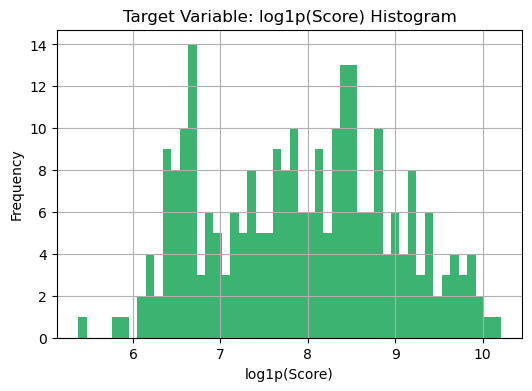

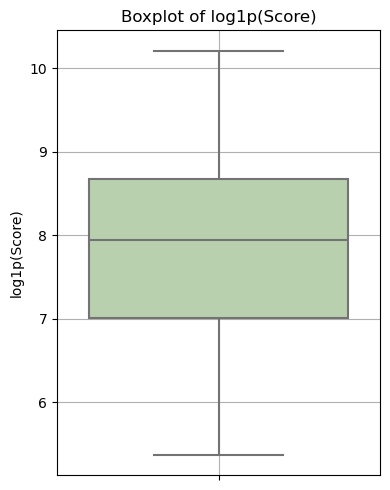

In [48]:
# y 변수 확인 (기본 통계량)
print(y.describe())

# 히스토그램 시각화
plt.figure(figsize=(6, 4))
y.hist(bins=50, color='mediumseagreen')
plt.title("Target Variable: log1p(Score) Histogram")
plt.xlabel("log1p(Score)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 박스플롯
plt.figure(figsize=(4, 5))
sns.boxplot(y=y, color="#B7D6A8", linewidth=1.5)
plt.title("Boxplot of log1p(Score)")
plt.ylabel("log1p(Score)")
plt.grid(True)
plt.tight_layout()
plt.show()

연속형 수치 변수: 22개
이진(OHE) 변수: 0개 → 히스토그램 제외


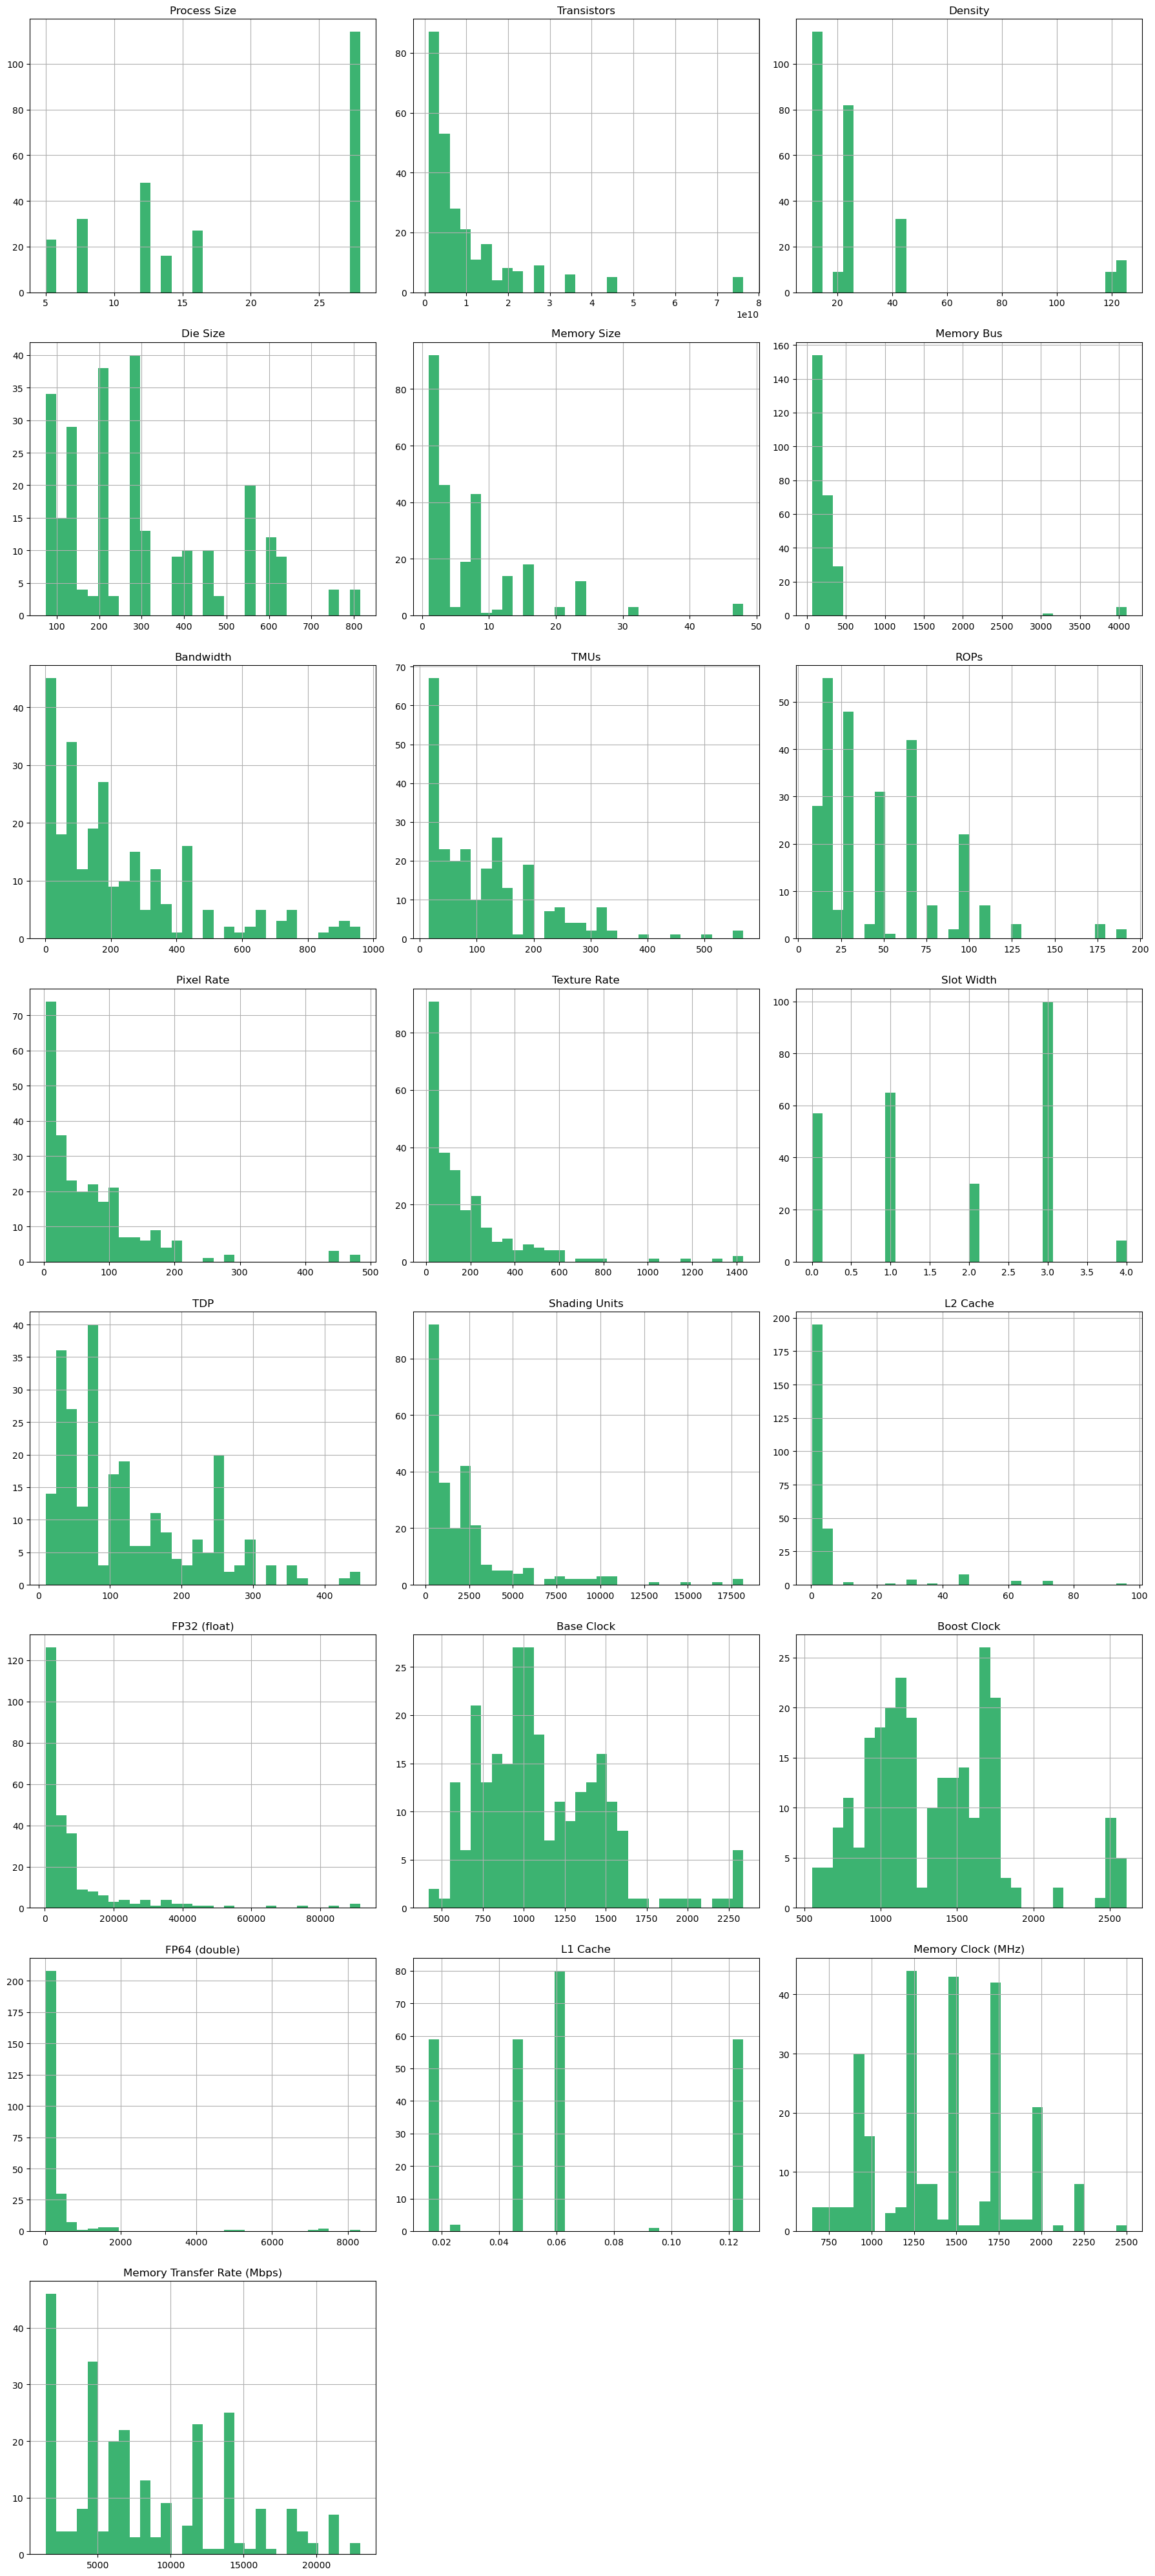

In [50]:
import math

# 진짜 수치형 컬럼만 (OHE bool/int 제외)
exclude_columns = ['Model Name', 'Score']
all_numeric = df.drop(columns=exclude_columns).select_dtypes(include='number').columns.tolist()

# OHE 결과(0/1) 컬럼 분리
binary_cols = [c for c in all_numeric if df[c].nunique() <= 2]
numerical_columns = [c for c in all_numeric if c not in binary_cols]

print(f"연속형 수치 변수: {len(numerical_columns)}개")
print(f"이진(OHE) 변수: {len(binary_cols)}개 → 히스토그램 제외")

# 한 행당 3개씩 히스토그램 출력
cols_per_row = 3
num_cols = len(numerical_columns)
num_rows = math.ceil(num_cols / cols_per_row)

fig, axs = plt.subplots(num_rows, cols_per_row, figsize=(18, 5 * num_rows))
axs = axs.flatten()

for i, col in enumerate(numerical_columns):
    df[col].hist(ax=axs[i], bins=30, color='mediumseagreen')
    axs[i].set_title(col)

for j in range(i + 1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

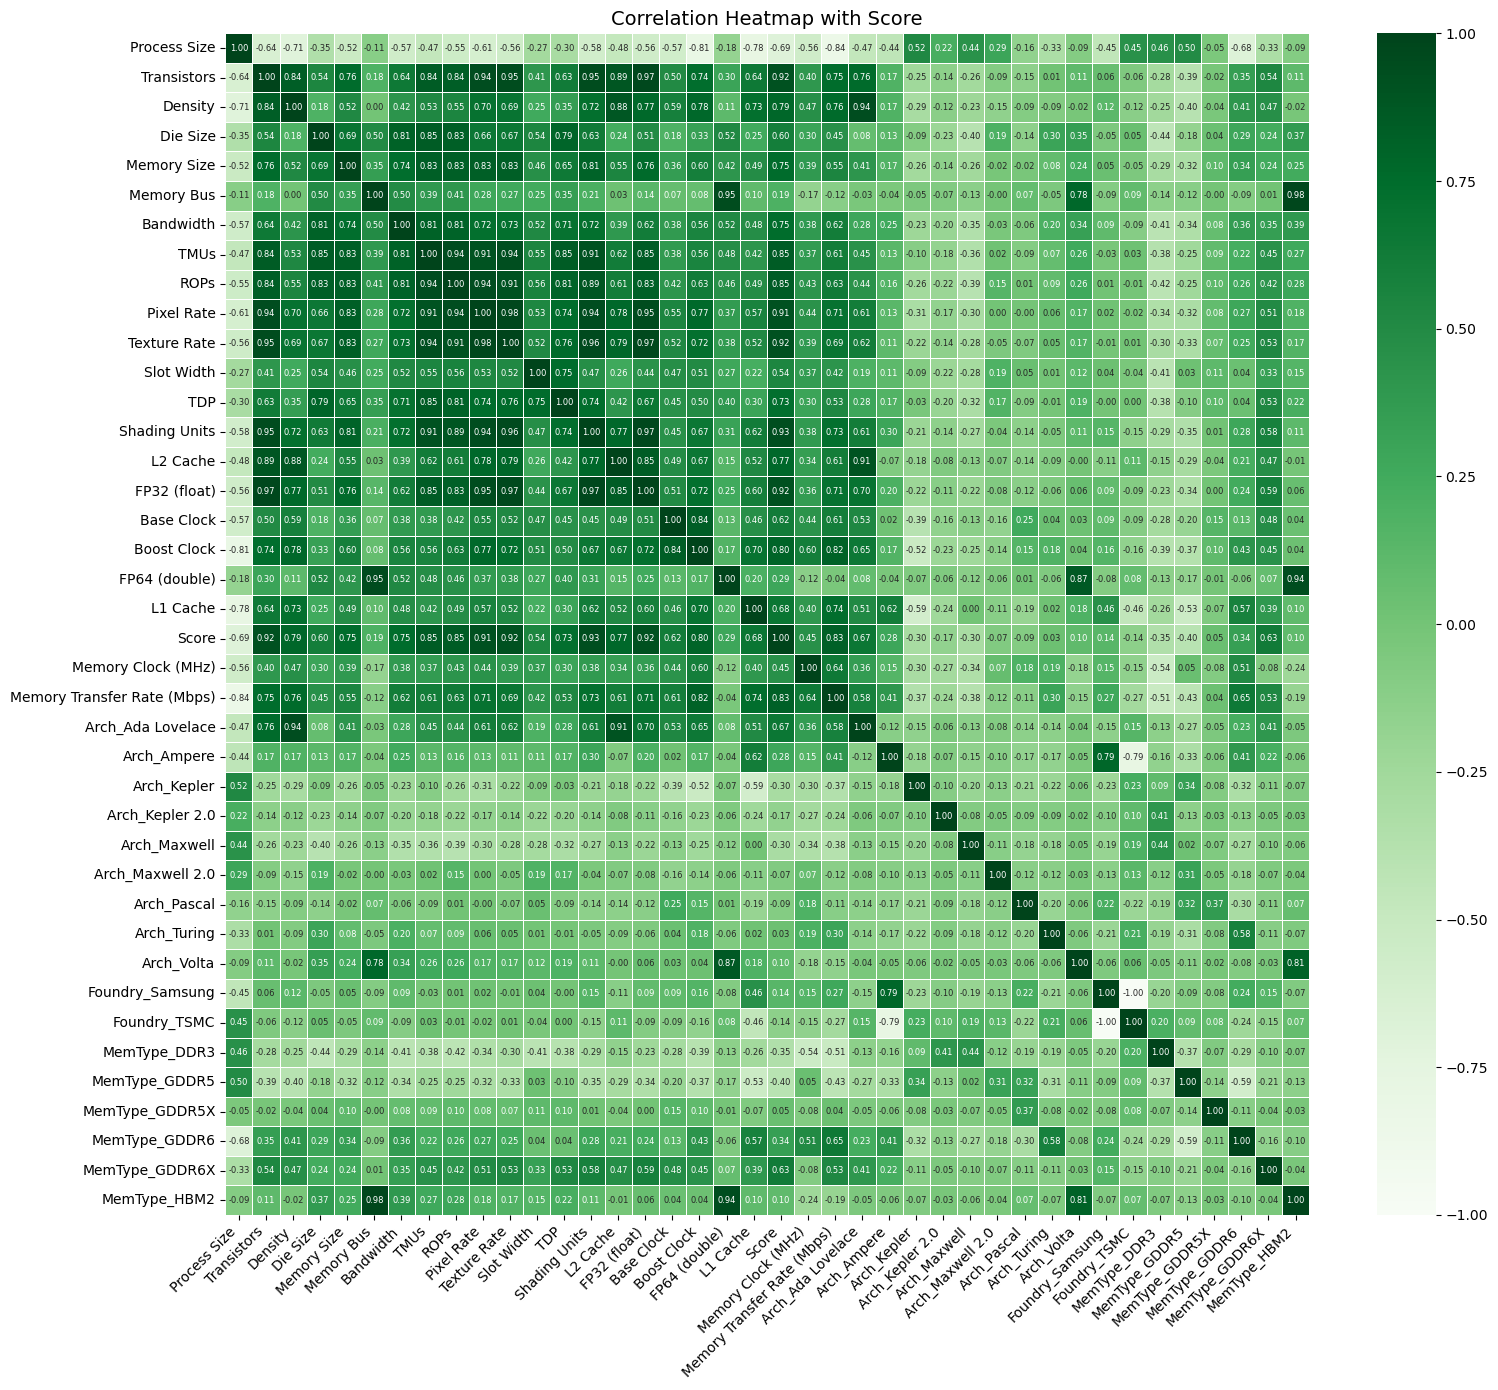

,Feature,Correlation with Score
0,Shading Units,0.931547
1,Transistors,0.918713
2,FP32 (float),0.918333
3,Texture Rate,0.917836
4,Pixel Rate,0.914727
5,TMUs,0.848255
6,ROPs,0.845990
7,Memory Transfer Rate (Mbps),0.825604
8,Boost Clock,0.801010
9,Density,0.786030


In [51]:
# 수치형 변수들 간 상관계수 행렬
corr = df.corr(numeric_only=True)

# Score 기준 상관계수만 따로 정리 (정렬)
target_corr = corr["Score"].drop("Score").sort_values(ascending=False)

# 히트맵 시각화 (변수 많아서 크기 확대)
plt.figure(figsize=(16, 14))
sns.heatmap(corr, 
            cmap='Greens',
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            annot_kws={"size": 6})
plt.title("Correlation Heatmap with Score", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Score와의 상관계수 테이블 출력
target_corr_df = target_corr.reset_index()
target_corr_df.columns = ['Feature', 'Correlation with Score']
display(target_corr_df)

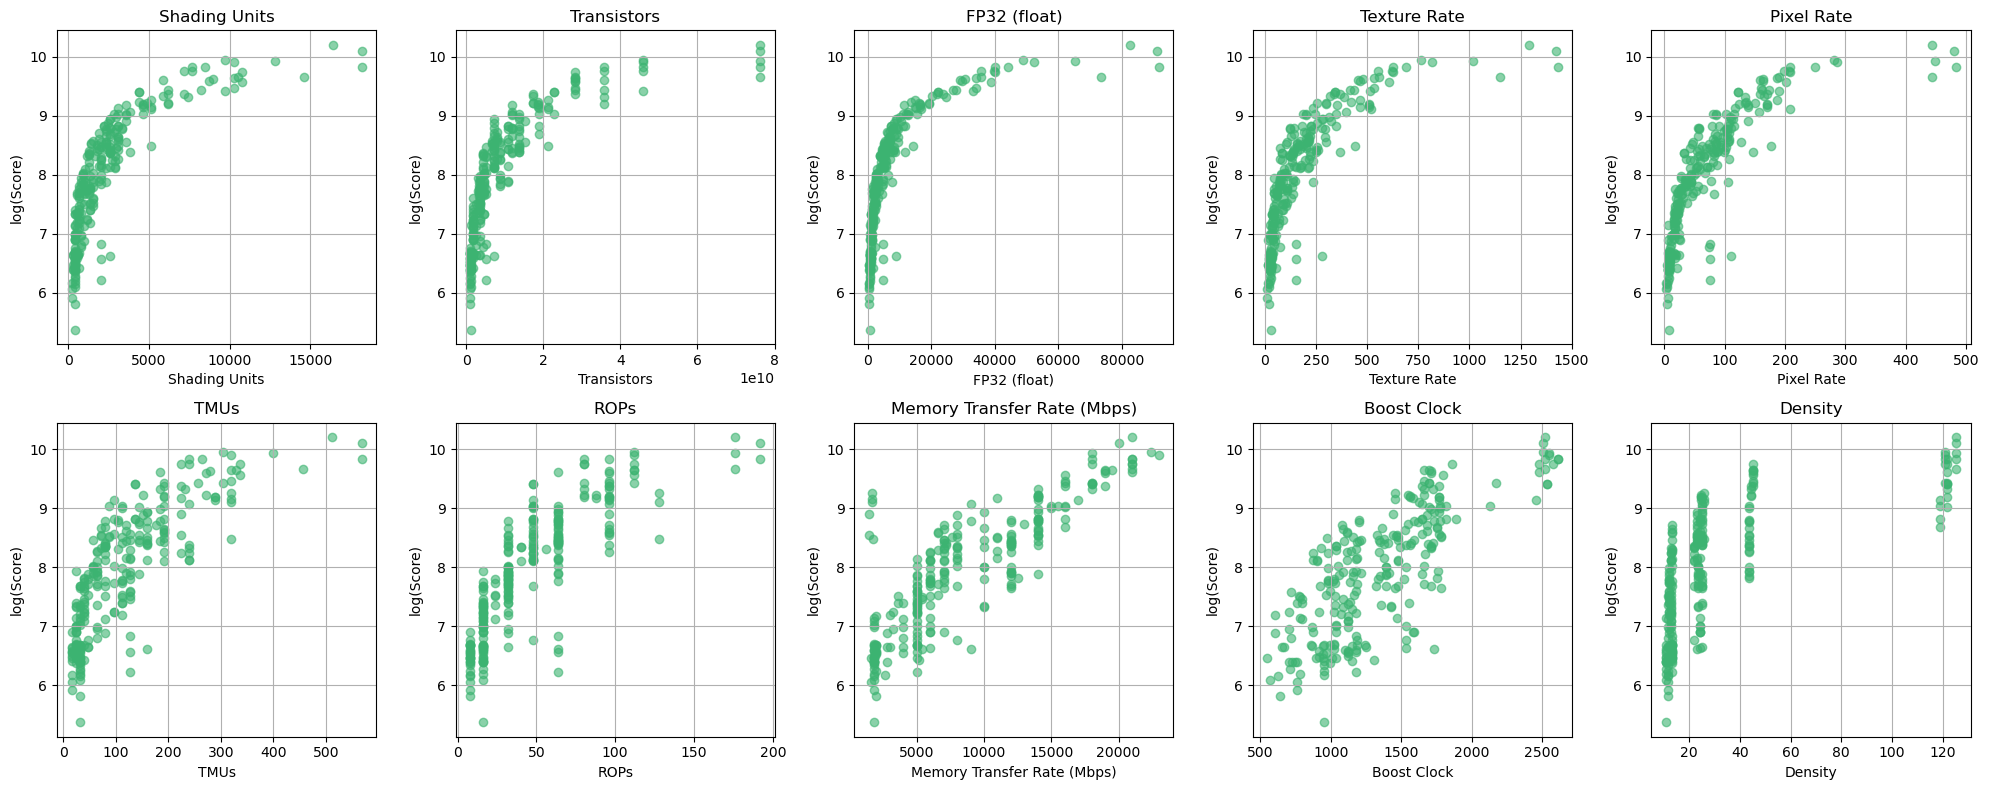

In [53]:
# 양의 상관관계 상위 10개 변수
top_positive = target_corr.head(10).index.tolist()

# 스캐터 플롯 (2행 5열)
plt.figure(figsize=(20, 8))
for i, col in enumerate(top_positive):
    plt.subplot(2, 5, i + 1)
    plt.scatter(df[col], y, alpha=0.6, color='mediumseagreen')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("log(Score)")
    plt.grid(True)

plt.tight_layout()
plt.show()

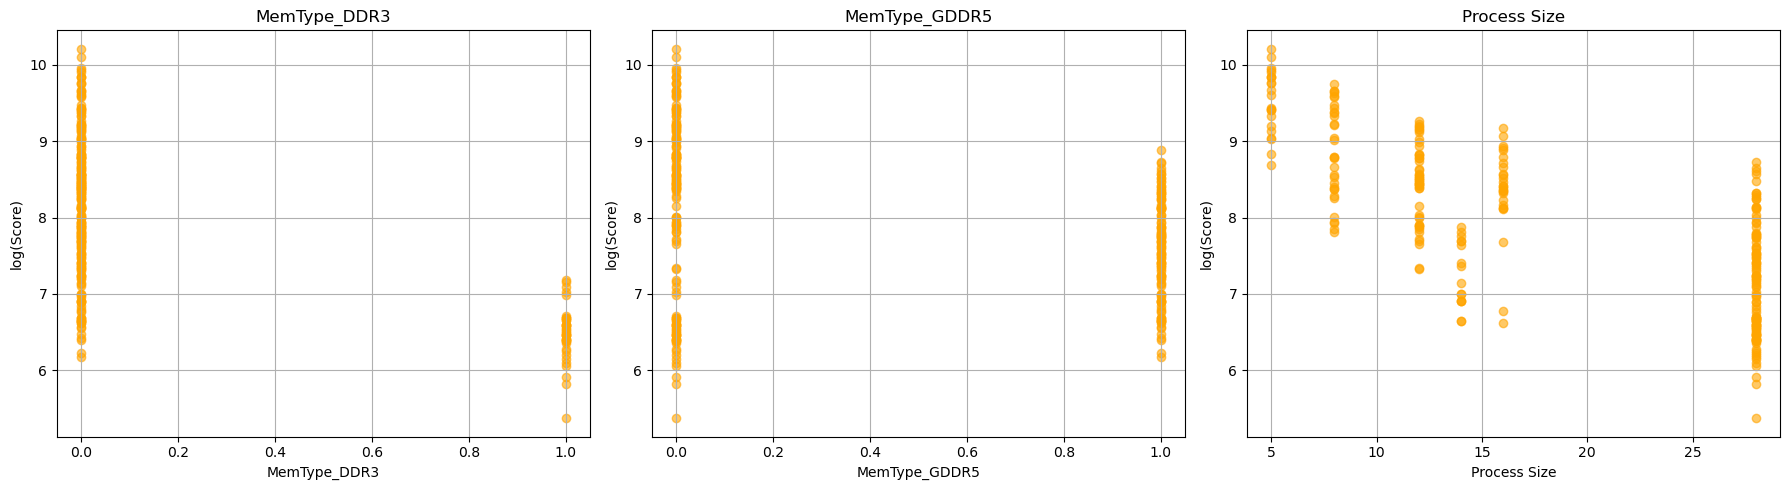

In [54]:
# 음의 상관관계 하위 3개 변수
bottom_negative = target_corr.tail(3).index.tolist()

# 스캐터 플롯 (1행 3열)
plt.figure(figsize=(18, 5))
for i, col in enumerate(bottom_negative):
    plt.subplot(1, 3, i + 1)
    plt.scatter(df[col], y, alpha=0.6, color='orange')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("log(Score)")
    plt.grid(True)

plt.tight_layout()
plt.show()

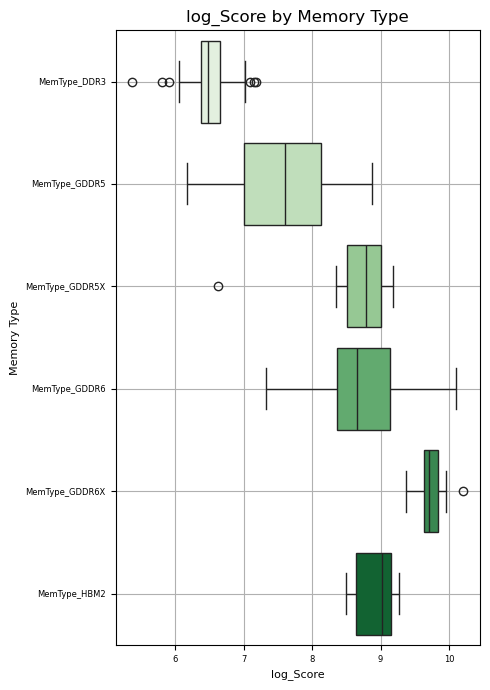

In [56]:
# 메모리 타입 관련 컬럼 추출
memtype_cols = [col for col in X.columns if col.startswith('MemType_')]

# log(FP32)와 메모리 타입 정보 결합
df_box = df[memtype_cols].copy()
df_box["log_Score"] = y  # log1p 된 타겟 변수 사용

# melt로 long-format 변환
df_melted = df_box.melt(id_vars=['log_Score'], 
                        value_vars=memtype_cols, 
                        var_name='MemType', 
                        value_name='IsType')
df_melted = df_melted[df_melted["IsType"] == 1]

# 초록 계열 그라데이션 팔레트
mem_palette = sns.color_palette("Greens", n_colors=df_melted['MemType'].nunique())
palette_dict = dict(zip(df_melted['MemType'].unique(), mem_palette))

# 박스플롯 시각화(가로 방향)
plt.figure(figsize=(5, 7))
sns.boxplot(data=df_melted, y='MemType', x='log_Score', hue='MemType', 
            palette=palette_dict, dodge=False, legend=False)  # hue 지정 + legend 제거

# 폰트 크기 조정
plt.title("log_Score by Memory Type", fontsize=12)
plt.xlabel("log_Score", fontsize=8)
plt.ylabel("Memory Type", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.grid(True)
plt.tight_layout()
plt.show()

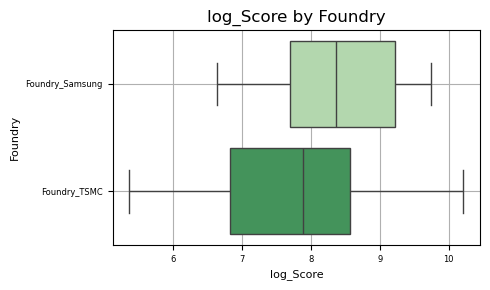

In [60]:
# Foundry 관련 컬럼 지정
foundry_cols = ['Foundry_Samsung', 'Foundry_TSMC']

# 박스플롯용 데이터프레임 구성
df_box_foundry = df[foundry_cols].copy()
df_box_foundry["log_Score"] = y

# melt 변환
df_melted_foundry = df_box_foundry.melt(id_vars=['log_Score'],
                                        value_vars=foundry_cols,
                                        var_name='Foundry',
                                        value_name='IsType')
df_melted_foundry = df_melted_foundry[df_melted_foundry["IsType"] == 1]

# 초록 계열 그라데이션 팔레트 생성
foundry_palette = sns.color_palette("Greens", n_colors=df_melted_foundry['Foundry'].nunique())
palette_dict_foundry = dict(zip(df_melted_foundry['Foundry'].unique(), foundry_palette))

# 박스플롯 시각화
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_melted_foundry, y='Foundry', x='log_Score', hue='Foundry',
            palette=palette_dict_foundry, dodge=False, legend=False)

# 폰트 크기 조정
plt.title("log_Score by Foundry", fontsize=12)
plt.xlabel("log_Score", fontsize=8)
plt.ylabel("Foundry", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)

plt.grid(True)
plt.tight_layout()
plt.show()

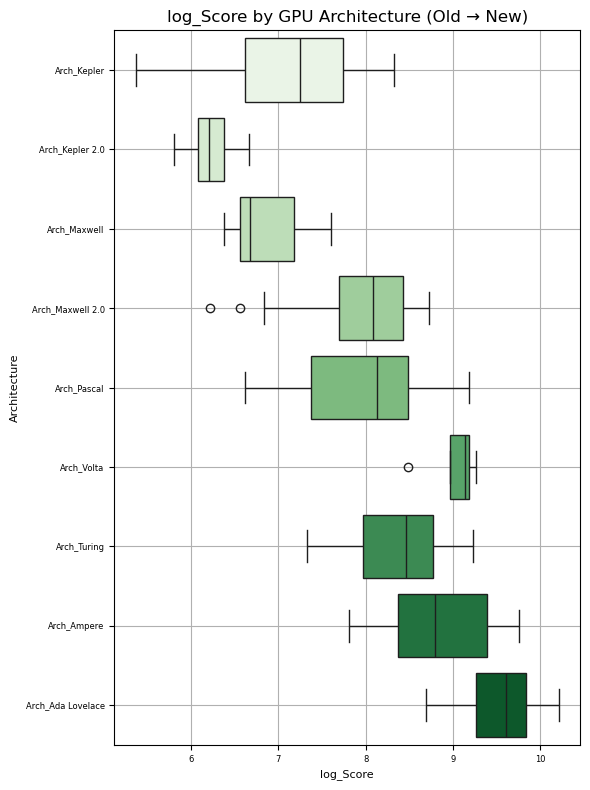

In [62]:
# Architecture 관련 컬럼 추출
arch_cols = [col for col in X.columns if col.startswith('Arch_')]

df_box_arch = df[arch_cols].copy()
df_box_arch["log_Score"] = y

df_melted_arch = df_box_arch.melt(id_vars=['log_Score'],
                                   value_vars=arch_cols,
                                   var_name='Architecture',
                                   value_name='IsType')
df_melted_arch = df_melted_arch[df_melted_arch["IsType"] == 1]

# 세대 순서로 정렬 (오래된 → 최신)
arch_order = [
    'Arch_Kepler', 'Arch_Kepler 2.0', 'Arch_Maxwell', 'Arch_Maxwell 2.0',
    'Arch_Pascal', 'Arch_Volta', 'Arch_Turing', 'Arch_Ampere', 'Arch_Ada Lovelace'
]
arch_order = [a for a in arch_order if a in df_melted_arch['Architecture'].unique()]

# 초록 계열 그라데이션 (오래된 → 최신, 진해짐)
arch_palette = sns.color_palette("Greens", n_colors=len(arch_order))
palette_dict_arch = dict(zip(arch_order, arch_palette))

plt.figure(figsize=(6, 8))
sns.boxplot(data=df_melted_arch, y='Architecture', x='log_Score',
            order=arch_order, hue='Architecture', 
            palette=palette_dict_arch, dodge=False, legend=False)
plt.title("log_Score by GPU Architecture (Old → New)", fontsize=12)
plt.xlabel("log_Score", fontsize=8)
plt.ylabel("Architecture", fontsize=8)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.grid(True)
plt.tight_layout()
plt.show()

In [64]:
# 연속형 + Ordinal(Slot Width) 변수 표준화
# float64(연속형) + int64(Ordinal Slot Width) 모두 포함
# bool/int32(OHE)는 0/1이라 표준화 제외 (해석 일관성)
cols_to_scale = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"표준화 대상 변수 ({len(cols_to_scale)}개):")
print(cols_to_scale)

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

# 표준화 결과 확인 (mean ≈ 0, std ≈ 1)
print("\n🔹 표준화 후 통계량:")
display(X_scaled[cols_to_scale].describe().loc[['mean', 'std']].round(3))

print("\n🔹 X_scaled 전체 미리보기:")
display(X_scaled.head())

표준화 대상 변수 (22개):
['Process Size', 'Transistors', 'Density', 'Die Size', 'Memory Size', 'Memory Bus', 'Bandwidth', 'TMUs', 'ROPs', 'Pixel Rate', 'Texture Rate', 'Slot Width', 'TDP', 'Shading Units', 'L2 Cache', 'FP32 (float)', 'Base Clock', 'Boost Clock', 'FP64 (double)', 'L1 Cache', 'Memory Clock (MHz)', 'Memory Transfer Rate (Mbps)']

🔹 표준화 후 통계량:


,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Shading Units,L2 Cache,FP32 (float),Base Clock,Boost Clock,FP64 (double),L1 Cache,Memory Clock (MHz),Memory Transfer Rate (Mbps)
mean,0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,0.000,0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002



🔹 X_scaled 전체 미리보기:


,Process Size,Transistors,Density,Die Size,Memory Size,Memory Bus,Bandwidth,TMUs,ROPs,Pixel Rate,Texture Rate,Slot Width,TDP,Shading Units,L2 Cache,FP32 (float),Base Clock,Boost Clock,FP64 (double),L1 Cache,Memory Clock (MHz),Memory Transfer Rate (Mbps),Arch_Ada Lovelace,Arch_Ampere,Arch_Kepler,Arch_Kepler 2.0,Arch_Maxwell,Arch_Maxwell 2.0,Arch_Pascal,Arch_Turing,Arch_Volta,Foundry_Samsung,Foundry_TSMC,MemType_DDR3,MemType_GDDR5,MemType_GDDR5X,MemType_GDDR6,MemType_GDDR6X,MemType_HBM2
723,1.075635,-0.656111,-0.632122,-0.962698,-0.673179,-0.255834,-0.924872,-0.84722,-0.857525,-0.837608,-0.723789,-1.400162,-0.964912,-0.694241,-0.397906,-0.565583,-1.294548,-1.414257,-0.315489,-1.22378,-1.310329,-1.210128,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0
724,1.075635,-0.656111,-0.632122,-0.962698,-0.795747,-0.255834,-0.924872,-0.84722,-0.857525,-0.851676,-0.744099,-1.400162,-1.092623,-0.694241,-0.397906,-0.573285,-1.624823,-1.724016,-0.319781,-1.22378,-1.310329,-1.210128,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0
727,1.075635,-0.656111,-0.632122,-0.962698,-0.673179,-0.255834,-0.924872,-0.84722,-0.857525,-0.830422,-0.713429,-1.400162,-0.964912,-0.694241,-0.397906,-0.561649,-1.068149,-1.256034,-0.313300,-1.22378,-1.310329,-1.210128,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0
728,1.075635,-0.656111,-0.632122,-0.962698,-0.673179,-0.255834,-0.924872,-0.84722,-0.857525,-0.830422,-0.713429,-1.400162,-0.964912,-0.694241,-0.397906,-0.561649,-1.068149,-1.256034,-0.313300,-1.22378,-1.310329,-1.210128,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0
729,1.075635,-0.656111,-0.632122,-0.962698,-0.795747,-0.255834,-0.924872,-0.84722,-0.857525,-0.813215,-0.688602,-1.400162,-0.826559,-0.694241,-0.397906,-0.552222,-0.732547,-0.877192,-0.308054,-1.22378,-1.310329,-1.210128,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0


In [66]:
# VIF 계산을 위해 bool → float 변환
X_scaled = X_scaled.astype(float)

# 더미 트랩 문제 해결: 각 OHE 그룹에서 참조 카테고리 1개씩 제거
# 참조는 보편적으로 빈도가 가장 높은 것 (또는 의미상 baseline이 되는 것)
X_scaled = X_scaled.drop(columns=[
    "Foundry_TSMC",        # Foundry 그룹 (TSMC가 다수, 참조)
    "MemType_GDDR5",       # Memory Type 그룹 (GDDR5가 다수, 참조)
    "Arch_Kepler",         # Architecture 그룹 (Kepler가 다수 + 가장 구세대, 참조)
])

print(f"📊 더미 트랩 처리 후 X shape: {X_scaled.shape}")
print(f"   제거된 참조 카테고리: Foundry_TSMC, MemType_GDDR5, Arch_Kepler")

📊 더미 트랩 처리 후 X shape: (260, 36)
   제거된 참조 카테고리: Foundry_TSMC, MemType_GDDR5, Arch_Kepler


In [68]:
# 다중공선성(VIF) 기반 단계적 변수 제거
X_reduced = X_scaled.copy()
iteration = 0
initial_n_features = X_reduced.shape[1]

# 초기 VIF 계산 및 출력
X_const_initial = add_constant(X_reduced)
vif_df_initial = pd.DataFrame({
    "feature": X_const_initial.columns,
    "VIF": [variance_inflation_factor(X_const_initial.values, i) 
            for i in range(X_const_initial.shape[1])]
})
vif_df_initial = vif_df_initial[vif_df_initial["feature"] != "const"]

print("📌 초기 VIF 값 (상위 15개):")
display(vif_df_initial.sort_values("VIF", ascending=False).head(15))

# 반복적으로 VIF 가장 높은 변수 제거
while True:
    X_const = add_constant(X_reduced)
    
    vif_df = pd.DataFrame({
        "feature": X_const.columns,
        "VIF": [variance_inflation_factor(X_const.values, i) 
                for i in range(X_const.shape[1])]
    })
    vif_df = vif_df[vif_df["feature"] != "const"]
    
    max_vif_row = vif_df.sort_values("VIF", ascending=False).iloc[0]
    max_vif = max_vif_row["VIF"]
    max_feature = max_vif_row["feature"]
    
    # 종료 조건: 모든 VIF가 10 이하
    if max_vif <= 10:
        break
    
    X_reduced = X_reduced.drop(columns=[max_feature])
    iteration += 1
    print(f"🔁 {iteration}회차 제거: '{max_feature}' (VIF: {max_vif:.2f})")

# 최종 VIF 표 출력
X_const_final = add_constant(X_reduced)
vif_df_final = pd.DataFrame({
    "feature": X_const_final.columns,
    "VIF": [variance_inflation_factor(X_const_final.values, i) 
            for i in range(X_const_final.shape[1])]
})
vif_df_final = vif_df_final[vif_df_final["feature"] != "const"]

print("\n📊 최종 VIF 값:")
display(vif_df_final.sort_values("VIF", ascending=False))

print("\n✅ 다중공선성 제거 완료!")
print(f"   총 제거 횟수: {iteration}회")
print(f"   변수 수: {initial_n_features}개 → {X_reduced.shape[1]}개")
print(f"\n🔹 남은 변수 목록:")
X_reduced.info()

📌 초기 VIF 값 (상위 15개):


C:\Users\7500\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\7500\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
1,Process Size,inf
31,Foundry_Samsung,inf
30,Arch_Volta,inf
29,Arch_Turing,inf
28,Arch_Pascal,inf
24,Arch_Ampere,inf
23,Arch_Ada Lovelace,inf
3,Density,6065.287890
16,FP32 (float),708.036893
11,Texture Rate,653.045762


C:\Users\7500\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\7500\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


🔁 1회차 제거: 'Process Size' (VIF: inf)
🔁 2회차 제거: 'Arch_Ada Lovelace' (VIF: 6183.52)
🔁 3회차 제거: 'FP32 (float)' (VIF: 704.28)
🔁 4회차 제거: 'Memory Transfer Rate (Mbps)' (VIF: 383.32)
🔁 5회차 제거: 'Pixel Rate' (VIF: 380.13)
🔁 6회차 제거: 'TMUs' (VIF: 172.44)
🔁 7회차 제거: 'MemType_HBM2' (VIF: 151.07)
🔁 8회차 제거: 'L1 Cache' (VIF: 84.19)
🔁 9회차 제거: 'Texture Rate' (VIF: 78.39)
🔁 10회차 제거: 'Transistors' (VIF: 64.72)
🔁 11회차 제거: 'FP64 (double)' (VIF: 35.82)
🔁 12회차 제거: 'ROPs' (VIF: 29.83)
🔁 13회차 제거: 'Density' (VIF: 20.87)
🔁 14회차 제거: 'Shading Units' (VIF: 18.35)
🔁 15회차 제거: 'Boost Clock' (VIF: 16.21)
🔁 16회차 제거: 'Die Size' (VIF: 10.45)

📊 최종 VIF 값:


,feature,VIF
9,Arch_Ampere,9.925609
19,MemType_GDDR6,9.911006
20,MemType_GDDR6X,6.873001
8,Memory Clock (MHz),6.340256
5,TDP,5.999712
2,Memory Bus,5.940835
16,Foundry_Samsung,5.567263
6,L2 Cache,5.467890
14,Arch_Turing,5.236165
3,Bandwidth,5.093843



✅ 다중공선성 제거 완료!
   총 제거 횟수: 16회
   변수 수: 36개 → 20개

🔹 남은 변수 목록:
<class 'pandas.core.frame.DataFrame'>
Index: 260 entries, 723 to 1425
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Memory Size         260 non-null    float64
 1   Memory Bus          260 non-null    float64
 2   Bandwidth           260 non-null    float64
 3   Slot Width          260 non-null    float64
 4   TDP                 260 non-null    float64
 5   L2 Cache            260 non-null    float64
 6   Base Clock          260 non-null    float64
 7   Memory Clock (MHz)  260 non-null    float64
 8   Arch_Ampere         260 non-null    float64
 9   Arch_Kepler 2.0     260 non-null    float64
 10  Arch_Maxwell        260 non-null    float64
 11  Arch_Maxwell 2.0    260 non-null    float64
 12  Arch_Pascal         260 non-null    float64
 13  Arch_Turing         260 non-null    float64
 14  Arch_Volta          260 non-null    float64


In [70]:
import statsmodels.api as sm

# Backward elimination (p-value 기반)
X_pval = X_reduced.copy()
y_target = y.copy()
iteration = 0
initial_n = X_pval.shape[1]

while True:
    X_const = add_constant(X_pval)
    
    # OLS 회귀 적합
    model = sm.OLS(y_target, X_const)
    results = model.fit()
    
    # const 제외한 p-value
    p_values = results.pvalues.drop("const")
    
    max_pval = p_values.max()
    max_feature = p_values.idxmax()
    
    # 종료 조건: 모든 변수 유의 (p ≤ 0.05)
    if max_pval <= 0.05:
        break
    
    X_pval = X_pval.drop(columns=[max_feature])
    iteration += 1
    print(f"🔁 {iteration}회차 제거: '{max_feature}' (p-value: {max_pval:.4f})")

print("\n✅ 유의하지 않은 변수 제거 완료!")
print(f"   총 제거 횟수: {iteration}회")
print(f"   변수 수: {initial_n}개 → {X_pval.shape[1]}개")
print(f"\n🔹 남은 변수 목록 ({X_pval.shape[1]}개):")
print(X_pval.columns.tolist())

# 최종 모델 요약 출력
final_model = sm.OLS(y_target, add_constant(X_pval)).fit()
print("\n📊 최종 모델 summary:")
print(final_model.summary())

🔁 1회차 제거: 'Arch_Volta' (p-value: 0.6239)
🔁 2회차 제거: 'Slot Width' (p-value: 0.3984)
🔁 3회차 제거: 'Arch_Turing' (p-value: 0.3326)
🔁 4회차 제거: 'Arch_Pascal' (p-value: 0.3268)
🔁 5회차 제거: 'Arch_Maxwell 2.0' (p-value: 0.3158)
🔁 6회차 제거: 'Arch_Maxwell' (p-value: 0.1696)
🔁 7회차 제거: 'Base Clock' (p-value: 0.1724)
🔁 8회차 제거: 'Memory Size' (p-value: 0.1507)
🔁 9회차 제거: 'Foundry_Samsung' (p-value: 0.1124)
🔁 10회차 제거: 'Arch_Ampere' (p-value: 0.0677)

✅ 유의하지 않은 변수 제거 완료!
   총 제거 횟수: 10회
   변수 수: 20개 → 10개

🔹 남은 변수 목록 (10개):
['Memory Bus', 'Bandwidth', 'TDP', 'L2 Cache', 'Memory Clock (MHz)', 'Arch_Kepler 2.0', 'MemType_DDR3', 'MemType_GDDR5X', 'MemType_GDDR6', 'MemType_GDDR6X']

📊 최종 모델 summary:
                            OLS Regression Results                            
Dep. Variable:                  Score   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     197.4
Date: 

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from math import sqrt
import numpy as np

# 🎯 최종 X, y 설정 (변수명 명확히)
X_final = X_pval
y_final = y_target

# 🧪 훈련/테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

# 🧠 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 🔮 예측 (log 스케일)
pred_train_log = model.predict(X_train)
pred_test_log = model.predict(X_test)

# 🔁 log1p → 원본 Score 스케일로 복원
y_train_actual = np.expm1(y_train)
y_test_actual = np.expm1(y_test)
pred_train_actual = np.expm1(pred_train_log)
pred_test_actual = np.expm1(pred_test_log)

# 📊 성능 평가 - log 스케일
train_r2_log = r2_score(y_train, pred_train_log)
test_r2_log = r2_score(y_test, pred_test_log)

# 📊 성능 평가 - 원본 Score 스케일
train_r2 = r2_score(y_train_actual, pred_train_actual)
test_r2 = r2_score(y_test_actual, pred_test_actual)
train_rmse = sqrt(mean_squared_error(y_train_actual, pred_train_actual))
test_rmse = sqrt(mean_squared_error(y_test_actual, pred_test_actual))
test_mae = mean_absolute_error(y_test_actual, pred_test_actual)

# 📊 5-Fold Cross-Validation (전체 데이터로, log 스케일)
cv_scores = cross_val_score(LinearRegression(), X_final, y_final, 
                             cv=5, scoring='r2')

# 결과 출력
print("=" * 50)
print("✅ 회귀 모델 성능 평가")
print("=" * 50)

print("\n🔹 [log 스케일] 모델 적합도")
print(f"   Train R² : {train_r2_log:.4f}")
print(f"   Test R²  : {test_r2_log:.4f}")

print("\n🔹 [원본 Score 스케일] 예측 성능")
print(f"   Train R²   : {train_r2:.4f}")
print(f"   Test R²    : {test_r2:.4f}")
print(f"   Train RMSE : {train_rmse:.2f}")
print(f"   Test RMSE  : {test_rmse:.2f}")
print(f"   Test MAE   : {test_mae:.2f}")

print("\n🔹 5-Fold Cross-Validation (log 스케일)")
print(f"   CV R² (각 fold): {[f'{s:.4f}' for s in cv_scores]}")
print(f"   CV R² 평균     : {cv_scores.mean():.4f}")
print(f"   CV R² 표준편차  : {cv_scores.std():.4f}")

✅ 회귀 모델 성능 평가

🔹 [log 스케일] 모델 적합도
   Train R² : 0.8896
   Test R²  : 0.8776

🔹 [원본 Score 스케일] 예측 성능
   Train R²   : 0.8688
   Test R²    : 0.8956
   Train RMSE : 1843.66
   Test RMSE  : 1167.40
   Test MAE   : 843.48

🔹 5-Fold Cross-Validation (log 스케일)
   CV R² (각 fold): ['0.8188', '0.6571', '0.6897', '0.7472', '-1.7209']
   CV R² 평균     : 0.2384
   CV R² 표준편차  : 0.9812


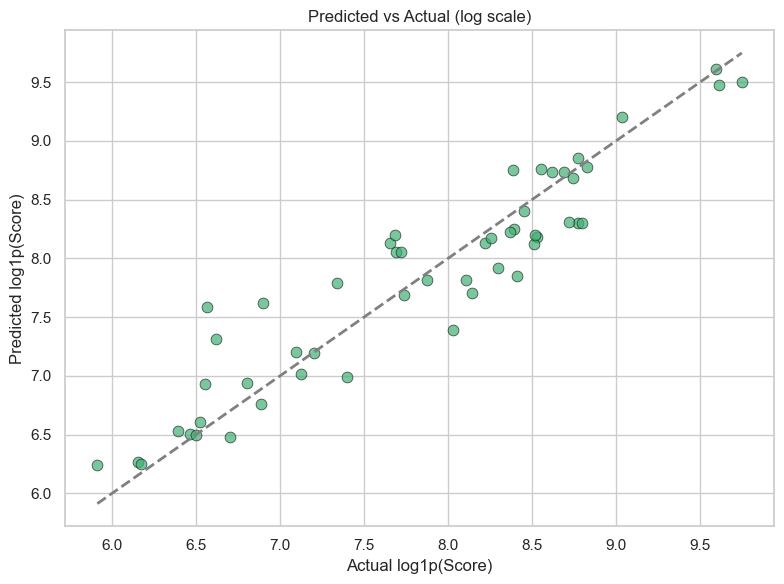

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# === 1. log 스케일 산점도 ===
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=pred_test_log, color="mediumseagreen", 
                s=60, edgecolor='k', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'gray', linestyle='--', linewidth=2)
plt.xlabel("Actual log1p(Score)")
plt.ylabel("Predicted log1p(Score)")
plt.title("Predicted vs Actual (log scale)")
plt.tight_layout()
plt.show()

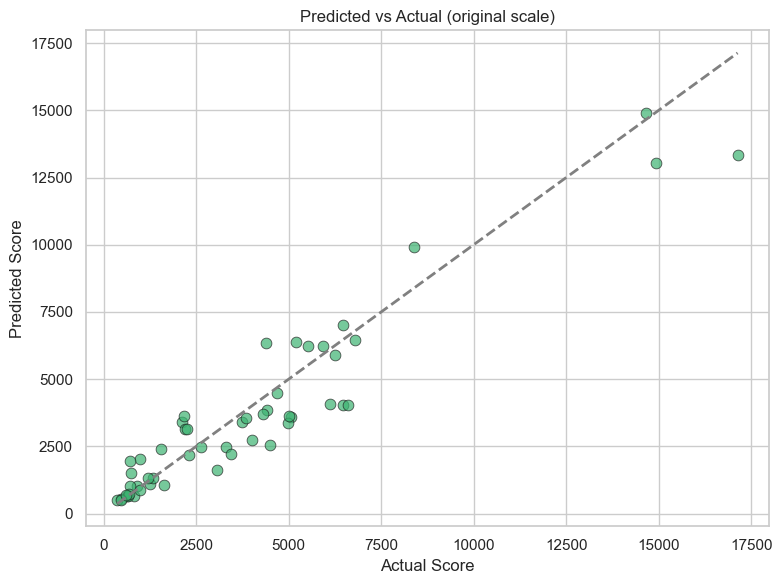

In [76]:
# === 2. 원본 Score 스케일 산점도 ===
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test_actual, y=pred_test_actual, color="mediumseagreen", 
                s=60, edgecolor='k', alpha=0.7)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'gray', linestyle='--', linewidth=2)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Predicted vs Actual (original scale)")
plt.tight_layout()
plt.show()

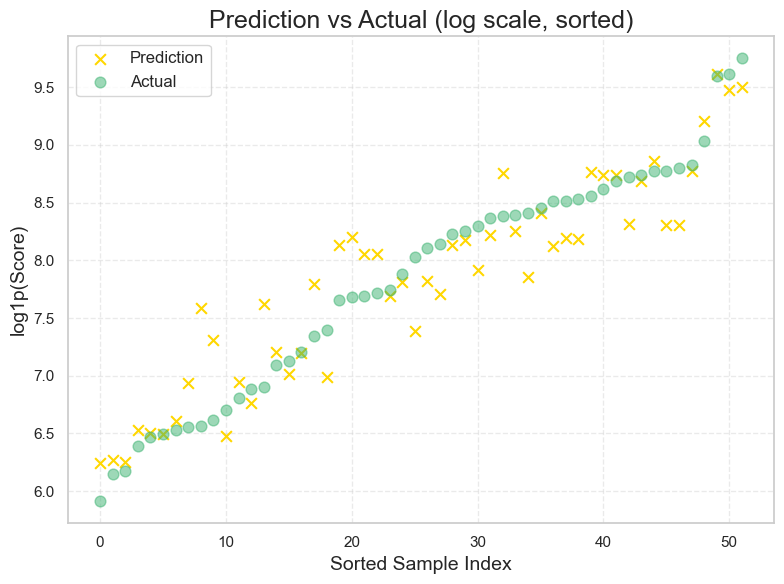

In [78]:
# === 3. log 스케일 정렬 비교 ===
result_log = pd.DataFrame({'actual': y_test, 'prediction': pred_test_log})
result_log = result_log.sort_values(by='actual').reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.scatter(result_log.index, result_log['prediction'], 
            marker='x', color='gold', label='Prediction', s=60)
plt.scatter(result_log.index, result_log['actual'], alpha=0.5, 
            marker='o', color='mediumseagreen', label='Actual', s=60)
plt.title("Prediction vs Actual (log scale, sorted)", fontsize=18)
plt.xlabel("Sorted Sample Index", fontsize=14)
plt.ylabel("log1p(Score)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

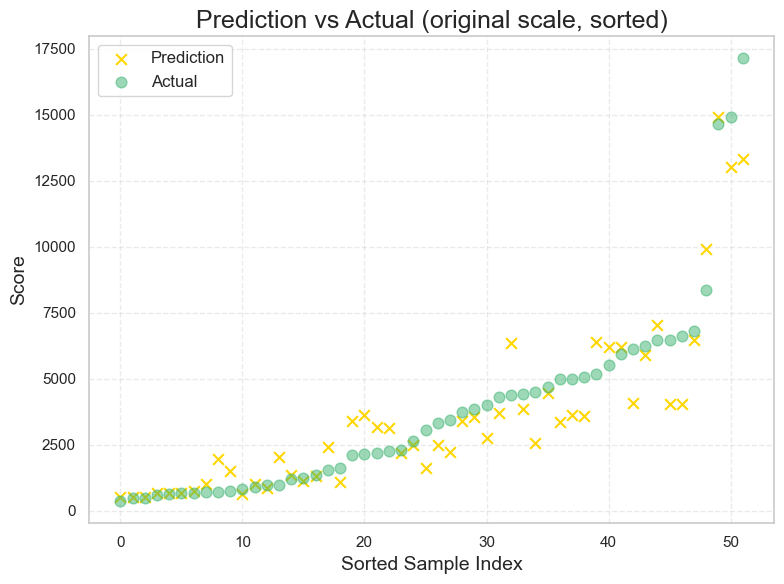

In [80]:
# === 4. 원본 Score 스케일 정렬 비교 ===
result_actual = pd.DataFrame({'actual': y_test_actual, 'prediction': pred_test_actual})
result_actual = result_actual.sort_values(by='actual').reset_index(drop=True)

plt.figure(figsize=(8, 6))
plt.scatter(result_actual.index, result_actual['prediction'], 
            marker='x', color='gold', label='Prediction', s=60)
plt.scatter(result_actual.index, result_actual['actual'], alpha=0.5, 
            marker='o', color='mediumseagreen', label='Actual', s=60)
plt.title("Prediction vs Actual (original scale, sorted)", fontsize=18)
plt.xlabel("Sorted Sample Index", fontsize=14)
plt.ylabel("Score", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

📋 전체 회귀 계수 (절댓값 기준 정렬):


,feature,coefficient
3,L2 Cache,0.062069
1,Bandwidth,0.137959
2,TDP,0.149391
0,Memory Bus,0.211196
5,Arch_Kepler 2.0,-0.233509
6,MemType_DDR3,-0.244622
4,Memory Clock (MHz),0.410795
8,MemType_GDDR6,0.641104
7,MemType_GDDR5X,0.920401
9,MemType_GDDR6X,1.524872


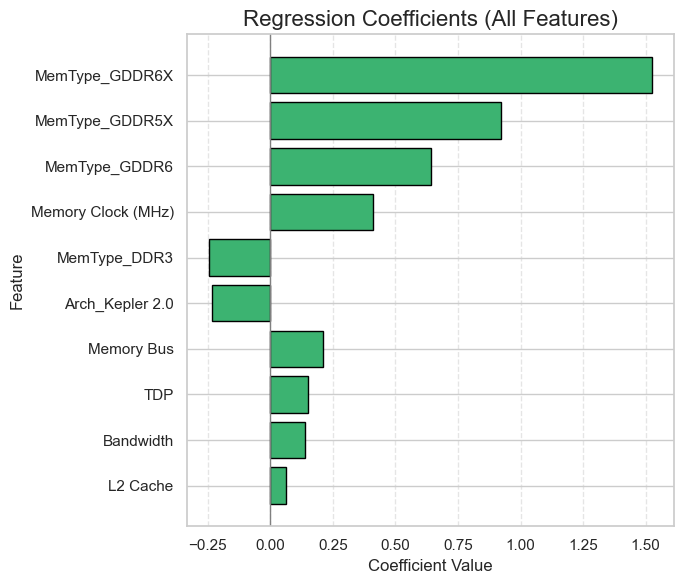

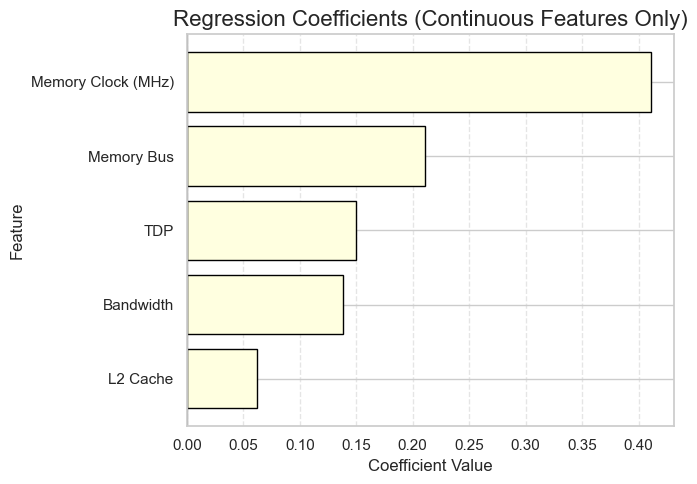

In [82]:
# 회귀 계수 추출
coef_df = pd.DataFrame({
    "feature": X_pval.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=True)

# 📋 전체 회귀 계수 표
print("📋 전체 회귀 계수 (절댓값 기준 정렬):")
display(coef_df)

# 시각화 - 전체 회귀 계수
plt.figure(figsize=(7, 6))
plt.barh(coef_df["feature"], coef_df["coefficient"], 
         color="mediumseagreen", edgecolor="black")
plt.axvline(0, color='gray', linewidth=1)
plt.title("Regression Coefficients (All Features)", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 비바이너리 변수만 추출 (OHE 결과 제외, 연속형/Ordinal만)
binary_features = [col for col in X_pval.columns if X_pval[col].nunique() == 2]
non_binary_mask = ~X_pval.columns.isin(binary_features)

coef_df_non_binary = pd.DataFrame({
    "feature": X_pval.columns[non_binary_mask],
    "coefficient": model.coef_[non_binary_mask]
}).sort_values(by="coefficient", key=abs, ascending=True)

# 시각화 - 비바이너리만
plt.figure(figsize=(7, 5))
plt.barh(coef_df_non_binary["feature"], coef_df_non_binary["coefficient"],
        color="lightyellow", edgecolor="black")
plt.axvline(0, color='gray', linewidth=1)
plt.title("Regression Coefficients (Continuous Features Only)", fontsize=16)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [84]:
# log1p(Score) 회귀식 출력
print("📘 회귀식 (log1p 스케일):")
print(f"\nlog1p(Score) = {model.intercept_:.4f}")
for name, coef in zip(X_pval.columns, model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f"             {sign} {abs(coef):.4f} · {name}")

📘 회귀식 (log1p 스케일):

log1p(Score) = 7.6653
             + 0.2112 · Memory Bus
             + 0.1380 · Bandwidth
             + 0.1494 · TDP
             + 0.0621 · L2 Cache
             + 0.4108 · Memory Clock (MHz)
             - 0.2335 · Arch_Kepler 2.0
             - 0.2446 · MemType_DDR3
             + 0.9204 · MemType_GDDR5X
             + 0.6411 · MemType_GDDR6
             + 1.5249 · MemType_GDDR6X


In [86]:
# 원본 Score 스케일 회귀식 (복원)
print("📘 회귀식 (원본 Score 스케일, 복원):")
print(f"\nScore = exp(")
print(f"    {model.intercept_:.4f}")
for name, coef in zip(X_pval.columns, model.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f"    {sign} {abs(coef):.4f} · {name}")
print(") - 1")

📘 회귀식 (원본 Score 스케일, 복원):

Score = exp(
    7.6653
    + 0.2112 · Memory Bus
    + 0.1380 · Bandwidth
    + 0.1494 · TDP
    + 0.0621 · L2 Cache
    + 0.4108 · Memory Clock (MHz)
    - 0.2335 · Arch_Kepler 2.0
    - 0.2446 · MemType_DDR3
    + 0.9204 · MemType_GDDR5X
    + 0.6411 · MemType_GDDR6
    + 1.5249 · MemType_GDDR6X
) - 1


In [88]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt
import pandas as pd
import numpy as np

# 모델 정의
models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0),
}

# 결과 저장
results = []

for name, m in models.items():
    m.fit(X_train, y_train)
    
    pred_train_log = m.predict(X_train)
    pred_test_log  = m.predict(X_test)
    
    pred_train_actual = np.expm1(pred_train_log)
    pred_test_actual  = np.expm1(pred_test_log)
    
    train_r2   = r2_score(y_train_actual, pred_train_actual)
    test_r2    = r2_score(y_test_actual,  pred_test_actual)
    train_rmse = sqrt(mean_squared_error(y_train_actual, pred_train_actual))
    test_rmse  = sqrt(mean_squared_error(y_test_actual,  pred_test_actual))
    
    cv_scores = cross_val_score(m, X_final, y_final, cv=5, scoring='r2')
    
    results.append({
        "Model":      name,
        "Train R²":   round(train_r2,   4),
        "Test R²":    round(test_r2,    4),
        "Train RMSE": round(train_rmse, 2),
        "Test RMSE":  round(test_rmse,  2),
        "CV R² 평균": round(cv_scores.mean(), 4),
        "CV R² std":  round(cv_scores.std(),  4),
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

,Train R²,Test R²,Train RMSE,Test RMSE,CV R² 평균,CV R² std
Model,,,,,,
Linear Regression,0.8688,0.8956,1843.66,1167.40,0.2384,0.9812
Ridge,0.7545,0.8177,2522.50,1542.50,0.6484,0.1830
Decision Tree,0.9509,0.5084,1127.77,2533.13,0.0868,0.3863
Random Forest,0.9365,0.8584,1282.88,1359.30,0.3450,0.4226
XGBoost,0.9951,0.9402,354.64,883.49,0.3672,0.4188


In [89]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# === XGBoost 튜닝 ===
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    xgb_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)
xgb_grid.fit(X_final, y_final)

print("🔍 XGBoost 최적 파라미터:", xgb_grid.best_params_)
print(f"   CV R² 최적값: {xgb_grid.best_score_:.4f}")

# === Random Forest 튜닝 ===
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5, scoring='r2', n_jobs=-1
)
rf_grid.fit(X_final, y_final)

print("\n🔍 Random Forest 최적 파라미터:", rf_grid.best_params_)
print(f"   CV R² 최적값: {rf_grid.best_score_:.4f}")

# === 튜닝된 모델로 성능 재평가 ===
tuned_models = {
    "XGBoost (tuned)":      xgb_grid.best_estimator_,
    "Random Forest (tuned)": rf_grid.best_estimator_,
}

tuned_results = []

for name, m in tuned_models.items():
    m.fit(X_train, y_train)
    
    pred_train_actual = np.expm1(m.predict(X_train))
    pred_test_actual  = np.expm1(m.predict(X_test))
    
    train_r2   = r2_score(y_train_actual, pred_train_actual)
    test_r2    = r2_score(y_test_actual,  pred_test_actual)
    train_rmse = sqrt(mean_squared_error(y_train_actual, pred_train_actual))
    test_rmse  = sqrt(mean_squared_error(y_test_actual,  pred_test_actual))
    cv_scores  = cross_val_score(m, X_final, y_final, cv=5, scoring='r2')
    
    tuned_results.append({
        "Model":      name,
        "Train R²":   round(train_r2,   4),
        "Test R²":    round(test_r2,    4),
        "Train RMSE": round(train_rmse, 2),
        "Test RMSE":  round(test_rmse,  2),
        "CV R² 평균": round(cv_scores.mean(), 4),
        "CV R² std":  round(cv_scores.std(),  4),
    })

# 이전 결과랑 합쳐서 비교
tuned_df = pd.DataFrame(tuned_results).set_index("Model")
print("\n📊 튜닝 전후 비교:")
display(pd.concat([results_df, tuned_df]))

🔍 XGBoost 최적 파라미터: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50, 'subsample': 0.7}
   CV R² 최적값: 0.4380

🔍 Random Forest 최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
   CV R² 최적값: 0.3459

📊 튜닝 전후 비교:


,Train R²,Test R²,Train RMSE,Test RMSE,CV R² 평균,CV R² std
Model,,,,,,
Linear Regression,0.8688,0.8956,1843.66,1167.40,0.2384,0.9812
Ridge,0.7545,0.8177,2522.50,1542.50,0.6484,0.1830
Decision Tree,0.9509,0.5084,1127.77,2533.13,0.0868,0.3863
Random Forest,0.9365,0.8584,1282.88,1359.30,0.3450,0.4226
XGBoost,0.9951,0.9402,354.64,883.49,0.3672,0.4188
XGBoost (tuned),0.9647,0.8877,956.04,1210.96,0.4380,0.3502
Random Forest (tuned),0.9119,0.8354,1511.11,1465.87,0.3459,0.4193


In [92]:
# Linear Regression CV 각 fold 확인
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
cv_detail = cross_val_score(LinearRegression(), X_final, y_final, cv=5, scoring='r2')
print(cv_detail)

[ 0.81878197  0.65710741  0.68965468  0.74721475 -1.72086674]


In [98]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
from math import sqrt
import numpy as np

y_bins = pd.qcut(y_final, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_split = list(skf.split(X_final, y_bins))

models = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "Decision Tree":     DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest":     RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, max_depth=5, random_state=42, verbosity=0),
    "XGBoost (tuned)":   XGBRegressor(learning_rate=0.1, max_depth=4, n_estimators=50,
                                      subsample=0.7, random_state=42, verbosity=0),
    "RF (tuned)":        RandomForestRegressor(max_depth=5, min_samples_leaf=1,
                                               min_samples_split=10, n_estimators=100,
                                               random_state=42),
}

results = []

for name, m in models.items():
    m.fit(X_train, y_train)

    pred_train_actual = np.expm1(m.predict(X_train))
    pred_test_actual  = np.expm1(m.predict(X_test))

    train_r2   = r2_score(y_train_actual, pred_train_actual)
    test_r2    = r2_score(y_test_actual,  pred_test_actual)
    train_rmse = sqrt(mean_squared_error(y_train_actual, pred_train_actual))
    test_rmse  = sqrt(mean_squared_error(y_test_actual,  pred_test_actual))

    cv_scores = cross_val_score(m, X_final, y_final, cv=skf_split, scoring='r2')

    results.append({
        "Model":      name,
        "Train R²":   round(train_r2,   4),
        "Test R²":    round(test_r2,    4),
        "Train RMSE": round(train_rmse, 2),
        "Test RMSE":  round(test_rmse,  2),
        "CV R² 평균": round(cv_scores.mean(), 4),
        "CV R² std":  round(cv_scores.std(),  4),
    })

results_df = pd.DataFrame(results).set_index("Model")
display(results_df)

,Train R²,Test R²,Train RMSE,Test RMSE,CV R² 평균,CV R² std
Model,,,,,,
Linear Regression,0.8688,0.8956,1843.66,1167.40,0.8741,0.0345
Ridge,0.7545,0.8177,2522.50,1542.50,0.8726,0.0342
Decision Tree,0.9509,0.5084,1127.77,2533.13,0.8480,0.0548
Random Forest,0.9365,0.8584,1282.88,1359.30,0.8814,0.0226
XGBoost,0.9951,0.9402,354.64,883.49,0.8703,0.0457
XGBoost (tuned),0.9647,0.8877,956.04,1210.96,0.8915,0.0278
RF (tuned),0.9119,0.8354,1511.11,1465.87,0.8810,0.0230
